# SQD Workflow: Stage 1 (circuit construction) + Stage 2 (sampling) + Stage 2B (sbd export) + Orbital-Ordering Experiment

- **Stage 1** (`stage1.py`): Hamiltonian (FCIDUMP, from PySCF or supplied) -> CCSD -> LUCJ ansatz -> transpiled circuit -> `.qpy` + JSON metadata.
- **Stage 2** (`stage2.py`): loads the `.qpy`, samples with Qiskit Aer, writes bitstrings + counts and a JSON diagnostics summary.
- **Stage 2B** (`stage2b.py`): splits Stage 2's sampled bitstrings into the alpha/beta determinant files the downstream C++ app `sbd` (r-ccs-cms/sbd) actually consumes, plus an HF-only calibration file and a ready-to-paste run command.
- A single `CONFIG` dict drives Stages 1/2/2B; `run_stage1(CONFIG)` / `run_stage2(CONFIG)` / `run_stage2b(CONFIG)` are importable for standalone scripts.
- Further down, a self-contained **orbital-ordering experiment** (N2 CAS(6,10) @ 1.55 A, 26 orderings x 5 seeds, fixed 225-determinant sbd budget, `seed_transpiler`-pinned and gate-validated for reproducibility) asks whether cheap, pre-sampling or post-sampling predictors can identify a good orbital-to-qubit ordering without running the expensive sbd diagonalisation itself. Headline: ordering changes subspace error by 19.98-96.58 mHa at fixed budget (signal-to-noise ~27x seed noise); the best predictors are post-sampling empirical-distribution metrics (e.g. `compactness99_beta`, regret 6.04 mHa, beating 69% of random single-ordering guesses) and the CCSD-initialized LUCJ energy (regret 7.77 mHa) - `retained_J` alone, despite being a clean structural/pre-sampling quantity, performs *worse than a random guess* on this run (regret 27.51 mHa).
- Out of scope: sampling-quality metrics beyond what's implemented above, orbital-ordering *optimisation* (this experiment compares a fixed set of orderings, it does not search), and the diagonalisation itself (`sbd` does that).


In [1]:
from pathlib import Path

import stage1
import stage2
import stage2b

print("stage1, stage2, and stage2b modules loaded.")

stage1, stage2, and stage2b modules loaded.


## CONFIG

Single dict driving all three stages. `fcidump_source` selects Stage 1's
entry point: `"pyscf"` builds an FCIDUMP from the molecular parameters below;
`"existing"` loads `existing_fcidump_path` directly (set `atom`/`basis` to
`None` in that case - they are only used for metadata bookkeeping).

`preset` selects a named system from `stage1.PRESETS` (`n2_equilibrium`,
`n2_stretched`, `n2_very_stretched`, `h2_sto3g`) which fills in
`atom`/`basis`/active-space fields - but only where the value here is still
`None`; set any of those fields explicitly to override the preset. This cell
runs `n2_equilibrium` as the primary demonstration; the cross-preset
comparison and the H2 calibration test further down use their own copies.

The `sbd_*` / `*_determinants` / `write_bdetfile` keys configure Stage 2B's
export to the downstream C++ app's `--adetfile`/`--bdetfile` format - see
`stage2b.py`'s module docstring for what that app expects.

In [2]:
CONFIG = {
    # --- Stage 1: Hamiltonian source ---
    "fcidump_source": "pyscf",  # "pyscf" or "existing"
    "existing_fcidump_path": None,  # used only when fcidump_source == "existing"

    # --- Stage 1: system preset (see stage1.PRESETS) ---
    "preset": None,

    # --- Stage 1: molecular parameters (Path A). None => filled in from `preset`. ---
    "atom": [["N", (0.0, 0.0, 0.0)], ["N", (0.0, 0.0, 1.55)]] ,
    "basis": "6-31g",
    "charge": 0,
    "spin": 0,
    "n_frozen_core": 4,
    "n_active_orbitals": 10,
    "n_active_electrons": 6,

    # --- Stage 1: CCSD / CASCI failsafe + exact-wavefunction baseline ---
    "run_casci_reference": True,
    "casci_reference_max_norb": 12,

    # --- Stage 1: circuit construction ---
    "optimization_level": 3,
    # Builds a second, unmasked (interaction_pairs=None) LUCJ ansatz alongside
    # the masked one, to quantify what the locality mask costs. See
    # stage1.build_unmasked_lucj_operator / print_ansatz_comparison.
    "build_unmasked_comparison": True,

    # --- Stage 1: output locations ---
    "output_dir": "outputs",
    "fcidump_filename": "n2_cas610_155.fcidump",
    "circuit_filename": "n2_cas610_155_lucj.qpy",

    # --- Stage 2: sampling ---
    # SQD literature commonly uses 1e5-1e7 shots; 10,000 is too few to expose
    # rare correlated configurations, so the default here is 1,000,000.
    "shots": 1_000_000,
    "seed": 42,

    # --- Stage 2: output locations ---
    "bitstring_filename": "n2_cas610_155_bitstrings.txt",

    # --- Stage 2: bitstring file format (this is a separate artefact from the
    # Stage 2B sbd export below; it may keep its header/counts for analysis) ---
    "bit_order_mode": "qiskit",  # Stage 2B requires this to stay 'qiskit'
    "output_separator": " ",
    "include_header": True,
    "include_counts": True,
    # When True, write one bitstring file per bit-order mode (mode in the
    # filename) so all four can be tried against other consumers at once.
    "emit_all_bit_order_variants": False,

    # --- Stage 2: diagnostics ---
    "top_k_report": 10,

    # --- Stage 2B: sbd export (see stage2b.py) ---
    # 'split' is CONFIRMED correct (verified against the sbd repo's
    # AlphaDets.txt example file - see stage2b module docstring). The
    # alternatives remain available as a fallback only.
    "sbd_bit_transform": "split",  # 'split' | 'split_reverse' | 'split_swap'
    # When True, write adet/bdet files for all three transforms at once.
    "emit_all_sbd_variants": False,
    # sbd defaults beta=alpha when --bdetfile is omitted; set False to skip
    # writing the beta file and rely on that default.
    "write_bdetfile": True,
    # Keep only the N most frequently sampled alpha/beta determinants (each
    # side independently). None = keep all. Matters because sbd's Hilbert
    # space is the *product* of the alpha and beta sets, so it grows as N^2.
    "max_determinants": None,
}

print("CONFIG:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

CONFIG:
  fcidump_source: pyscf
  existing_fcidump_path: None
  preset: None
  atom: [['N', (0.0, 0.0, 0.0)], ['N', (0.0, 0.0, 1.55)]]
  basis: 6-31g
  charge: 0
  spin: 0
  n_frozen_core: 4
  n_active_orbitals: 10
  n_active_electrons: 6
  run_casci_reference: True
  casci_reference_max_norb: 12
  optimization_level: 3
  build_unmasked_comparison: True
  output_dir: outputs
  fcidump_filename: n2_cas610_155.fcidump
  circuit_filename: n2_cas610_155_lucj.qpy
  shots: 1000000
  seed: 42
  bitstring_filename: n2_cas610_155_bitstrings.txt
  bit_order_mode: qiskit
  output_separator:  
  include_header: True
  include_counts: True
  emit_all_bit_order_variants: False
  top_k_report: 10
  sbd_bit_transform: split
  emit_all_sbd_variants: False
  write_bdetfile: True
  max_determinants: None


## Stage 1: circuit construction

Builds/loads the FCIDUMP, analyses the exact (CASCI) wavefunction's
concentration as a physical baseline, runs CCSD in the active space (with a
loud failsafe warning if CCSD diverges relative to CASCI), builds the masked
LUCJ operator (`n_reps=None`, `optimize=False` - mandatory) plus an unmasked
comparison ansatz, transpiles both, prints a masked-vs-unmasked comparison
table, and serialises both to `.qpy` + JSON metadata (the masked circuit's
metadata records the unmasked `.qpy` path so Stage 2 can find it). Every step
prints its own diagnostics.

In [3]:
stage1_result = stage1.run_stage1(CONFIG)

print()
print("Stage 1 outputs:")
print(f"  FCIDUMP         : {stage1_result.fcidump_path}")
print(f"  QPY (masked)    : {stage1_result.qpy_path}")
print(f"  Metadata (masked): {stage1_result.metadata_path}")
if stage1_result.unmasked_stats is not None:
    print(f"  QPY (unmasked)  : {stage1_result.unmasked_stats.qpy_path}")
    print(f"  Metadata (unmasked): {stage1_result.unmasked_stats.metadata_path}")

No preset selected (CONFIG['preset'] is falsy); using explicit CONFIG values.
=== Stage 1 / Path A: generating FCIDUMP from PySCF ===
  HF energy               = -108.5873225618
  Active space orbitals   = 10
  Active space electrons  = (3, 3) (alpha, beta)
  Frozen core orbitals    = 4
  FCIDUMP written to      = outputs/n2_cas610_155.fcidump
Reloading active-space Hamiltonian from outputs/n2_cas610_155.fcidump ...
Parsing outputs/n2_cas610_155.fcidump
Parsing outputs/n2_cas610_155.fcidump
  norb (active) = 10
  nelec (active) = (3, 3)
  core energy = -98.7678301361
  active-space RHF energy = -108.5873225618
Analysing exact (CASCI) wavefunction concentration ...
  CI space dimension            = 14400
  Weight on top determinant     = 0.759639
  Determinants for 90% weight   = 6
  Determinants for 99% weight   = 74
  Determinants for 99.9% weight = 278
Running CCSD in the active space ...


  CCSD converged      = True
  CCSD total energy   = -108.8280746430
  CCSD correlation E  = -0.2407520813
Computing CASCI (exact diagonalisation) reference in the active space ...
  CASCI (exact) energy = -108.8443004314
Locality mask (heavy-hex zig-zag layout):
  aa (same-spin) pairs retained: 9 / 45 possible -> [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7), (7, 8), (8, 9)]
  ab (opposite-spin) pairs retained: 3 / 100 possible -> [(0, 0), (4, 4), (8, 8)]
Building LUCJ operator (n_reps=None, optimize=False; MANDATORY, do not change) ...
  Actual n_reps chosen by full-rank factorisation: 42
Building Qiskit circuit (HF prep + UCJ + measure_all) ...
  Circuit built: 20 qubits, depth 3
Pre-transpilation:  depth=3, two-qubit gates=0


Transpilation path: preset pass manager with ffsim.qiskit.PRE_INIT pre-init stage.
Post-transpilation: depth=1354, two-qubit gates=7618
Masked ansatz variational energy: -108.6463168013
Building UNMASKED LUCJ operator (interaction_pairs=None; comparison only) ...
  Actual n_reps chosen by full-rank factorisation: 42
Building Qiskit circuit (HF prep + UCJ + measure_all) ...
  Circuit built: 20 qubits, depth 3
Pre-transpilation:  depth=3, two-qubit gates=0


Transpilation path: preset pass manager with ffsim.qiskit.PRE_INIT pre-init stage.
Post-transpilation: depth=1699, two-qubit gates=8836
Unmasked ansatz variational energy: -108.8140506878

=== Masked vs unmasked LUCJ ansatz comparison ===
                                        masked          unmasked
n_reps                                      42                42
circuit depth                             1354              1699
two-qubit gate count                      7618              8836
variational energy             -108.6463168013   -108.8140506878
CCSD energy (reference)        -108.8280746430   -108.8280746430
CASCI energy (reference)       -108.8443004314   -108.8443004314
error vs CCSD (mHa)                   181.7578           14.0240

Circuit serialised to outputs/n2_cas610_155_lucj_unmasked.qpy
Metadata written to outputs/n2_cas610_155_lucj_unmasked.json
Validating round-trip of outputs/n2_cas610_155_lucj_unmasked.qpy ...
  Round-trip validation PASSED: qubits, depth, a

  Round-trip validation PASSED: qubits, depth, and operation counts match.
=== Stage 1 complete ===

Stage 1 outputs:
  FCIDUMP         : outputs/n2_cas610_155.fcidump
  QPY (masked)    : outputs/n2_cas610_155_lucj.qpy
  Metadata (masked): outputs/n2_cas610_155_lucj.json
  QPY (unmasked)  : outputs/n2_cas610_155_lucj_unmasked.qpy
  Metadata (unmasked): outputs/n2_cas610_155_lucj_unmasked.json


## Stage 2: sampling

Loads the masked `.qpy` circuit produced above, samples it with
`AerSimulator` (prints wall-clock sampling time), prints all diagnostics
(unique bitstring count, top-10, particle-number checks). If Stage 1 built an
unmasked comparison circuit, its path is read from the masked circuit's
metadata and it is sampled too, with a side-by-side sampling-diversity
comparison (unique bitstring count, top-1 fraction) printed at the end.
Writes the bitstring file(s) + JSON summary for each circuit sampled.

`CONFIG["qpy_path"]` is set from Stage 1's result so this cell can also be
re-run standalone against any previously produced `.qpy` file.

In [4]:
CONFIG["qpy_path"] = str(stage1_result.qpy_path)

stage2_result = stage2.run_stage2(CONFIG)

Loading metadata from outputs/n2_cas610_155_lucj.json ...
  norb = 10, nelec = [3, 3]
--- Sampling MASKED circuit ---
Loading circuit from outputs/n2_cas610_155_lucj.qpy ...
  qubits = 20, depth = 1354
Sampling with AerSimulator: shots=1000000, seed=42 ...


  Got 134 unique bitstrings from 1000000 shots in 3.30s.
Total shots: 1000000
Unique bitstrings: 134
Top 10 bitstrings:
  00000001110000000111  count=977423  prob=0.977423
  00000010110000001011  count=3912  prob=0.003912
  00000101010000010101  count=3623  prob=0.003623
  00000101010000000111  count=2576  prob=0.002576
  00000001110000010101  count=2442  prob=0.002442
  00000001110100000101  count=1393  prob=0.001393
  01000001010000000111  count=1363  prob=0.001363
  00100000110000000111  count=922  prob=0.000922
  00000001110010000011  count=911  prob=0.000911
  00000001110000110100  count=497  prob=0.000497
Fraction of shots on the single most frequent bitstring: 0.977423
Particle-number check (fraction of shots, by weight):
  total set bits == 6: 100.0000%
  alpha set bits == 3: 100.0000%
  beta set bits == 3: 100.0000%
Bitstring file written to outputs/n2_cas610_155_bitstrings.txt (134 unique bitstrings)
JSON summary written to outputs/n2_cas610_155_bitstrings.json
--- Sampling U

  Got 509 unique bitstrings from 1000000 shots in 3.49s.
Total shots: 1000000
Unique bitstrings: 509
Top 10 bitstrings:
  00000001110000000111  count=791925  prob=0.791925
  00000101010000010101  count=45697  prob=0.045697
  00000010110000001011  count=45268  prob=0.045268
  00000010110000010101  count=12072  prob=0.012072
  00000101010000001011  count=11828  prob=0.011828
  00000110010000011001  count=6907  prob=0.006907
  00000011010000010011  count=5493  prob=0.005493
  00000100110000001101  count=5435  prob=0.005435
  00001001100000100110  count=5136  prob=0.005136
  00001001100000010101  count=3918  prob=0.003918
Fraction of shots on the single most frequent bitstring: 0.791925
Particle-number check (fraction of shots, by weight):
  total set bits == 6: 100.0000%
  alpha set bits == 3: 100.0000%
  beta set bits == 3: 100.0000%
Bitstring file written to outputs/n2_cas610_155_bitstrings_unmasked.txt (509 unique bitstrings)
JSON summary written to outputs/n2_cas610_155_bitstrings_unm

## Stage 2B: sbd export

Splits Stage 2's sampled bitstrings into the alpha/beta determinant files
the downstream C++ app (`sbd`, `apps/chemistry_tpb_selected_basis_diagonalization`)
actually consumes via `--adetfile`/`--bdetfile`: one bitstring per line, no
header, no counts. Prints the product-space diagnostics (sbd forms the
tensor product of the alpha and beta sectors - confirmed in the sbd README),
applies `CONFIG["max_determinants"]` truncation if set, and guarantees the
Hartree-Fock determinant is present in both files (sbd uses it as the
Davidson initial state after sorting).

Also writes an HF-only calibration file and prints a ready-to-paste `mpirun`
command for the files this run produced.

In [5]:
sbd_export = stage2b.run_stage2b(CONFIG)
hf_calibration = stage2b.write_hf_only_determinant(CONFIG)
stage2b.print_sbd_command(CONFIG, sbd_export)

=== Stage 2B: sbd export ===
Loaded 134 unique full bitstrings from outputs/n2_cas610_155_bitstrings.txt
Loading metadata from outputs/n2_cas610_155_lucj.json ...
  norb = 10, nelec = [3, 3]
--- sbd export: sbd_bit_transform='split' ---
  alpha determinants kept: 39/39 (100.0000% of sampled weight)
  beta determinants kept:  43/43 (100.0000% of sampled weight)
Determinant file written to outputs/n2_cas610_155_adets.txt (39 determinants)
Determinant file written to outputs/n2_cas610_155_bdets.txt (43 determinants)
Product-space diagnostics (tensor product of alpha x beta sectors):
  unique full bitstrings sampled  : 134
  unique alpha determinants       : 39
  unique beta determinants        : 43
  implied product-space dimension : 1677 (= 39 x 43)
  product_dim / unique_full_bitstrings ratio: 12.51x
  full CI space dimension (C(norb,na)*C(norb,nb)): 14400
  product space as % of full CI space: 11.6458%
sbd export diagnostics written to outputs/n2_cas610_155_sbd_export.json
=== Stage 2B

## H2 calibration test: the smallest possible end-to-end run

`h2_sto3g` (H2 at 0.74 A, sto-3g, no frozen core, norb=2, nelec=(1,1)) is the
smallest system this pipeline can build - useful for a fast, cheap sanity
check of the whole chain, and specifically for calibrating the sbd bit
ordering: `write_hf_only_determinant` below writes a single-determinant file
that, fed to sbd, must reproduce the printed Hartree-Fock energy exactly. If
it doesn't, try `CONFIG["sbd_bit_transform"] = "split_reverse"` or
`"split_swap"` (though `"split"` is already confirmed correct against the
sbd repository's own example file - see `stage2b.py`).

This runs Stage 1 -> Stage 2 -> Stage 2B end to end on its own `CONFIG` copy
so it doesn't disturb the primary `n2_equilibrium` outputs above.

In [6]:
h2_config = dict(CONFIG)  # fresh copy, same CONFIG pattern
h2_config["preset"] = "h2_sto3g"
h2_config["atom"] = None
h2_config["basis"] = None
h2_config["n_frozen_core"] = None
h2_config["n_active_orbitals"] = None
h2_config["n_active_electrons"] = None
h2_config["fcidump_filename"] = "h2_sto3g.fcidump"
h2_config["circuit_filename"] = "h2_sto3g_lucj.qpy"
h2_config["bitstring_filename"] = "h2_sto3g_bitstrings.txt"

h2_stage1 = stage1.run_stage1(h2_config)
h2_config["qpy_path"] = str(h2_stage1.qpy_path)
h2_stage2 = stage2.run_stage2(h2_config)
h2_sbd_export = stage2b.run_stage2b(h2_config)
h2_hf_calibration = stage2b.write_hf_only_determinant(h2_config)
stage2b.print_sbd_command(h2_config, h2_sbd_export)

Active preset: 'h2_sto3g'
=== Stage 1 / Path A: generating FCIDUMP from PySCF ===
  HF energy               = -1.1167593074
  Active space orbitals   = 2
  Active space electrons  = (1, 1) (alpha, beta)
  Frozen core orbitals    = 0
  FCIDUMP written to      = outputs/h2_sto3g.fcidump
Reloading active-space Hamiltonian from outputs/h2_sto3g.fcidump ...
Parsing outputs/h2_sto3g.fcidump
Parsing outputs/h2_sto3g.fcidump
  norb (active) = 2
  nelec (active) = (1, 1)
  core energy = 0.7151043391
  active-space RHF energy = -1.1167593074
Analysing exact (CASCI) wavefunction concentration ...
  CI space dimension            = 4
  Weight on top determinant     = 0.987334
  Determinants for 90% weight   = 1
  Determinants for 99% weight   = 2
  Determinants for 99.9% weight = 2
Running CCSD in the active space ...
  CCSD converged      = True
  CCSD total energy   = -1.1372839986
  CCSD correlation E  = -0.0205246912
Computing CASCI (exact diagonalisation) reference in the active space ...
  CA

  Got 4 unique bitstrings from 1000000 shots in 0.19s.
Total shots: 1000000
Unique bitstrings: 4
Top 4 bitstrings:
  0101  count=998459  prob=0.998459
  1010  count=766  prob=0.000766
  0110  count=390  prob=0.000390
  1001  count=385  prob=0.000385
Fraction of shots on the single most frequent bitstring: 0.998459
Particle-number check (fraction of shots, by weight):
  total set bits == 2: 100.0000%
  alpha set bits == 1: 100.0000%
  beta set bits == 1: 100.0000%
Bitstring file written to outputs/h2_sto3g_bitstrings.txt (4 unique bitstrings)
JSON summary written to outputs/h2_sto3g_bitstrings.json
--- Sampling UNMASKED circuit ---
Loading circuit from outputs/h2_sto3g_lucj_unmasked.qpy ...
  qubits = 4, depth = 17
Sampling with AerSimulator: shots=1000000, seed=42 ...
  Got 2 unique bitstrings from 1000000 shots in 0.19s.
Total shots: 1000000
Unique bitstrings: 2
Top 2 bitstrings:
  0101  count=987482  prob=0.987482
  1010  count=12518  prob=0.012518
Fraction of shots on the single mos

## Cross-preset comparison: quantifying HF-dominance vs. the locality mask

The single-preset run above showed the sampler heavily concentrated on one
bitstring. Two candidate explanations were proposed:

  (a) N2 in this active space is genuinely HF-dominated at this geometry
  (b) the locality mask discards most Jastrow elements, collapsing the
      ansatz back toward HF

This section runs Stage 1 + Stage 2 for all three presets
(`n2_equilibrium`, `n2_stretched`, `n2_very_stretched`), stretching the N-N
bond to reduce HF character (a), while the masked-vs-unmasked ansatz
comparison built into each Stage 1 run isolates the mask's own cost (b).
Each preset gets its own output filenames so nothing is overwritten.

Note: `n2_very_stretched` is expected to trip the CCSD-vs-CASCI divergence
failsafe (single-reference CCSD breaks down for stretched N2) - the loud
warning is expected there, and its ansatz/sampling numbers should be read as
"unreliable input" rather than a mask-quality measurement.

In [7]:
preset_results: dict[str, dict] = {}

for preset_name in ["n2_equilibrium", "n2_stretched", "n2_very_stretched"]:
    print()
    print("#" * 78)
    print(f"# Preset: {preset_name}")
    print("#" * 78)

    preset_config = dict(CONFIG)  # fresh copy per preset; same CONFIG pattern
    preset_config["preset"] = preset_name
    preset_config["atom"] = None
    preset_config["basis"] = None
    preset_config["n_frozen_core"] = None
    preset_config["n_active_orbitals"] = None
    preset_config["n_active_electrons"] = None
    preset_config["fcidump_filename"] = f"{preset_name}.fcidump"
    preset_config["circuit_filename"] = f"{preset_name}_lucj.qpy"
    preset_config["bitstring_filename"] = f"{preset_name}_bitstrings.txt"

    s1 = stage1.run_stage1(preset_config)
    preset_config["qpy_path"] = str(s1.qpy_path)
    s2 = stage2.run_stage2(preset_config)
    s2b = stage2b.run_stage2b(preset_config)

    preset_results[preset_name] = {"stage1": s1, "stage2": s2, "stage2b": s2b}

print()
print("Cross-preset comparison complete.")


##############################################################################
# Preset: n2_equilibrium
##############################################################################
Active preset: 'n2_equilibrium'
=== Stage 1 / Path A: generating FCIDUMP from PySCF ===


  HF energy               = -108.8677463470
  Active space orbitals   = 6
  Active space electrons  = (3, 3) (alpha, beta)
  Frozen core orbitals    = 4
  FCIDUMP written to      = outputs/n2_equilibrium.fcidump
Reloading active-space Hamiltonian from outputs/n2_equilibrium.fcidump ...
Parsing outputs/n2_equilibrium.fcidump
Parsing outputs/n2_equilibrium.fcidump
  norb (active) = 6
  nelec (active) = (3, 3)
  core energy = -97.5489212436
  active-space RHF energy = -108.8677463470
Analysing exact (CASCI) wavefunction concentration ...
  CI space dimension            = 400
  Weight on top determinant     = 0.939267
  Determinants for 90% weight   = 1
  Determinants for 99% weight   = 15
  Determinants for 99.9% weight = 24
Running CCSD in the active space ...
  CCSD converged      = True
  CCSD total energy   = -108.9459113986
  CCSD correlation E  = -0.0781650516
Computing CASCI (exact diagonalisation) reference in the active space ...
  CASCI (exact) energy = -108.9467159424
Locality 

Transpilation path: preset pass manager with ffsim.qiskit.PRE_INIT pre-init stage.
Post-transpilation: depth=371, two-qubit gates=1192
Masked ansatz variational energy: -108.8978714008
Building UNMASKED LUCJ operator (interaction_pairs=None; comparison only) ...
  Actual n_reps chosen by full-rank factorisation: 18
Building Qiskit circuit (HF prep + UCJ + measure_all) ...
  Circuit built: 12 qubits, depth 3
Pre-transpilation:  depth=3, two-qubit gates=0
Transpilation path: preset pass manager with ffsim.qiskit.PRE_INIT pre-init stage.
Post-transpilation: depth=516, two-qubit gates=1716
Unmasked ansatz variational energy: -108.9454183878

=== Masked vs unmasked LUCJ ansatz comparison ===
                                        masked          unmasked
n_reps                                      18                18
circuit depth                              371               516
two-qubit gate count                      1192              1716
variational energy             -108.89787140

  Round-trip validation PASSED: qubits, depth, and operation counts match.
Circuit serialised to outputs/n2_equilibrium_lucj.qpy
Metadata written to outputs/n2_equilibrium_lucj.json
Validating round-trip of outputs/n2_equilibrium_lucj.qpy ...
  Round-trip validation PASSED: qubits, depth, and operation counts match.
=== Stage 1 complete ===
Loading metadata from outputs/n2_equilibrium_lucj.json ...
  norb = 6, nelec = [3, 3]
--- Sampling MASKED circuit ---
Loading circuit from outputs/n2_equilibrium_lucj.qpy ...
  qubits = 12, depth = 371
Sampling with AerSimulator: shots=1000000, seed=42 ...


  Got 49 unique bitstrings from 1000000 shots in 0.32s.
Total shots: 1000000
Unique bitstrings: 49
Top 10 bitstrings:
  000111000111  count=994406  prob=0.994406
  011001000111  count=817  prob=0.000817
  000111011001  count=794  prob=0.000794
  010101000111  count=454  prob=0.000454
  000111010101  count=443  prob=0.000443
  001011001011  count=374  prob=0.000374
  010101010101  count=349  prob=0.000349
  001101001101  count=306  prob=0.000306
  010011010011  count=251  prob=0.000251
  001011000111  count=188  prob=0.000188
Fraction of shots on the single most frequent bitstring: 0.994406
Particle-number check (fraction of shots, by weight):
  total set bits == 6: 100.0000%
  alpha set bits == 3: 100.0000%
  beta set bits == 3: 100.0000%
Bitstring file written to outputs/n2_equilibrium_bitstrings.txt (49 unique bitstrings)
JSON summary written to outputs/n2_equilibrium_bitstrings.json
--- Sampling UNMASKED circuit ---
Loading circuit from outputs/n2_equilibrium_lucj_unmasked.qpy ...
 

...

  Got 70 unique bitstrings from 1000000 shots in 0.31s.
Total shots: 1000000
Unique bitstrings: 70
Top 10 bitstrings:
  000111000111  count=984080  prob=0.984080
  001101001101  count=2748  prob=0.002748
  010011010011  count=2425  prob=0.002425
  000111001011  count=1176  prob=0.001176
  001011000111  count=1121  prob=0.001121
  010011000111  count=698  prob=0.000698
  000111010011  count=697  prob=0.000697
  000111001101  count=665  prob=0.000665
  001101000111  count=650  prob=0.000650
  010101010011  count=640  prob=0.000640
Fraction of shots on the single most frequent bitstring: 0.984080
Particle-number check (fraction of shots, by weight):
  total set bits == 6: 100.0000%
  alpha set bits == 3: 100.0000%
  beta set bits == 3: 100.0000%
Bitstring file written to outputs/n2_stretched_bitstrings.txt (70 unique bitstrings)
JSON summary written to outputs/n2_stretched_bitstrings.json
--- Sampling UNMASKED circuit ---
Loading circuit from outputs/n2_stretched_lucj_unmasked.qpy ...
  q

  Got 96 unique bitstrings from 1000000 shots in 0.38s.
Total shots: 1000000
Unique bitstrings: 96
Top 10 bitstrings:
  000111000111  count=796389  prob=0.796389
  001101001101  count=24401  prob=0.024401
  010011010011  count=24137  prob=0.024137
  001011001011  count=10292  prob=0.010292
  010101010101  count=10220  prob=0.010220
  010011010101  count=9880  prob=0.009880
  001011001101  count=9755  prob=0.009755
  001011010011  count=9717  prob=0.009717
  010101001101  count=9694  prob=0.009694
  001101010101  count=9674  prob=0.009674
Fraction of shots on the single most frequent bitstring: 0.796389
Particle-number check (fraction of shots, by weight):
  total set bits == 6: 100.0000%
  alpha set bits == 3: 100.0000%
  beta set bits == 3: 100.0000%
Bitstring file written to outputs/n2_stretched_bitstrings_unmasked.txt (96 unique bitstrings)
JSON summary written to outputs/n2_stretched_bitstrings_unmasked.json

=== Masked vs unmasked sampling diversity ===
                           

Transpilation path: preset pass manager with ffsim.qiskit.PRE_INIT pre-init stage.
Post-transpilation: depth=367, two-qubit gates=1176
Masked ansatz variational energy: -108.3498563718
Building UNMASKED LUCJ operator (interaction_pairs=None; comparison only) ...
  Actual n_reps chosen by full-rank factorisation: 18
Building Qiskit circuit (HF prep + UCJ + measure_all) ...
  Circuit built: 12 qubits, depth 3
Pre-transpilation:  depth=3, two-qubit gates=0
Transpilation path: preset pass manager with ffsim.qiskit.PRE_INIT pre-init stage.
Post-transpilation: depth=511, two-qubit gates=1700
Unmasked ansatz variational energy: -108.4460794061

=== Masked vs unmasked LUCJ ansatz comparison ===
                                        masked          unmasked
n_reps                                      18                18
circuit depth                              367               511
two-qubit gate count                      1176              1700
variational energy             -108.34985637

  Got 240 unique bitstrings from 1000000 shots in 0.35s.
Total shots: 1000000
Unique bitstrings: 240
Top 10 bitstrings:
  000111000111  count=876940  prob=0.876940
  001011000111  count=10688  prob=0.010688
  000111001011  count=10528  prob=0.010528
  010101010101  count=8682  prob=0.008682
  101010000111  count=6716  prob=0.006716
  000111101010  count=6668  prob=0.006668
  001011001011  count=6382  prob=0.006382
  000111110010  count=4298  prob=0.004298
  110010000111  count=4238  prob=0.004238
  001101001101  count=3853  prob=0.003853
Fraction of shots on the single most frequent bitstring: 0.876940
Particle-number check (fraction of shots, by weight):
  total set bits == 6: 100.0000%
  alpha set bits == 3: 100.0000%
  beta set bits == 3: 100.0000%
Bitstring file written to outputs/n2_very_stretched_bitstrings.txt (240 unique bitstrings)
JSON summary written to outputs/n2_very_stretched_bitstrings.json
--- Sampling UNMASKED circuit ---
Loading circuit from outputs/n2_very_stretched_

  Got 102 unique bitstrings from 1000000 shots in 0.58s.
Total shots: 1000000
Unique bitstrings: 102
Top 10 bitstrings:
  000111000111  count=328808  prob=0.328808
  011001011001  count=80942  prob=0.080942
  100110100110  count=61537  prob=0.061537
  001101001101  count=33305  prob=0.033305
  010011010011  count=32222  prob=0.032222
  010101010011  count=19289  prob=0.019289
  010011010101  count=19199  prob=0.019199
  001011001101  count=18439  prob=0.018439
  001101001011  count=18244  prob=0.018244
  001101010101  count=17416  prob=0.017416
Fraction of shots on the single most frequent bitstring: 0.328808
Particle-number check (fraction of shots, by weight):
  total set bits == 6: 100.0000%
  alpha set bits == 3: 100.0000%
  beta set bits == 3: 100.0000%
Bitstring file written to outputs/n2_very_stretched_bitstrings_unmasked.txt (102 unique bitstrings)
JSON summary written to outputs/n2_very_stretched_bitstrings_unmasked.json

=== Masked vs unmasked sampling diversity ===
         

In [8]:
print(f"{'preset':20s}{'HF':>13s}{'CCSD':>13s}{'CASCI':>13s}{'exact top wt':>13s}")
for name, r in preset_results.items():
    s1 = r["stage1"]
    m = s1.metadata
    exact_top = s1.exact_wavefunction.weight_on_top_determinant if s1.exact_wavefunction else float("nan")
    print(f"{name:20s}{m['hf_energy']:>13.6f}{m['ccsd_energy']:>13.6f}{m['casci_reference_energy']:>13.6f}{exact_top:>13.4f}")

print()
print(f"{'preset':20s}{'masked E err(mHa)':>19s}{'unmasked E err(mHa)':>21s}")
for name, r in preset_results.items():
    s1 = r["stage1"]
    ccsd_e = s1.metadata["ccsd_energy"]
    masked_err = 1000 * (s1.masked_stats.variational_energy - ccsd_e)
    unmasked_err = 1000 * (s1.unmasked_stats.variational_energy - ccsd_e) if s1.unmasked_stats else float("nan")
    print(f"{name:20s}{masked_err:>19.4f}{unmasked_err:>21.4f}")

print()
print(f"{'preset':20s}{'masked uniq':>13s}{'unmasked uniq':>15s}{'masked top1':>13s}{'unmasked top1':>15s}")
for name, r in preset_results.items():
    s2 = r["stage2"]
    masked = s2["masked"]
    unmasked = s2["unmasked"]
    u_uniq = unmasked["unique_bitstrings"] if unmasked else float("nan")
    u_top1 = unmasked["top1_fraction"] if unmasked else float("nan")
    print(f"{name:20s}{masked['unique_bitstrings']:>13d}{u_uniq:>15}{masked['top1_fraction']:>13.4f}{u_top1:>15.4f}")

print()
print(f"{'preset':20s}{'n_adets':>10s}{'n_bdets':>10s}{'product dim':>13s}{'% of full CI':>14s}")
for name, r in preset_results.items():
    diag = r["stage2b"]["variants"][r["stage2b"]["default_transform"]]["diagnostics"]
    print(
        f"{name:20s}{diag['n_alpha_determinants']:>10d}{diag['n_beta_determinants']:>10d}"
        f"{diag['product_space_dimension']:>13d}{diag['product_space_pct_of_full_ci']:>14.4f}"
    )

preset                         HF         CCSD        CASCI exact top wt
n2_equilibrium        -108.867746  -108.945911  -108.946716       0.9393
n2_stretched          -108.587323  -108.801058  -108.811675       0.7705
n2_very_stretched     -108.309601  -108.764548  -108.726795       0.3455

preset                masked E err(mHa)  unmasked E err(mHa)
n2_equilibrium                  48.0400               0.4930
n2_stretched                   154.8266              11.0087
n2_very_stretched              414.6913             318.4682

preset                masked uniq  unmasked uniq  masked top1  unmasked top1
n2_equilibrium                 49             75       0.9944         0.9408
n2_stretched                   70             96       0.9841         0.7964
n2_very_stretched             240            102       0.8769         0.3288

preset                 n_adets   n_bdets  product dim  % of full CI
n2_equilibrium              17        17          289       72.2500
n2_stretched     

## Outputs and next steps

Per run (primary demo uses `n2_cas66*`; the H2 calibration uses
`h2_sto3g*`; the cross-preset section uses `<preset_name>*`), `outputs/`
contains:

- `*.fcidump` - the active-space Hamiltonian.
- `*_lucj.qpy` / `.json` - the **masked** Stage 1 circuit + metadata.
- `*_lucj_unmasked.qpy` / `.json` - the unmasked comparison circuit + metadata (comparison-only).
- `*_bitstrings.txt` / `.json` (+ `*_bitstrings_unmasked.*`) - Stage 2's own
  bitstring + counts artefact, for this notebook's analysis only. **Not**
  what sbd reads.
- `*_adets.txt` / `*_bdets.txt` (+ `*_sbd_export.json`) - **Stage 2B's sbd
  export**: one determinant per line, no header, no counts, sorted ascending
  (HF first). This is what `--adetfile`/`--bdetfile` actually take.
- `*_hf_only_adets.txt` / `*_hf_only_bdets.txt` - the single-determinant
  calibration file (see the H2 section above).

**sbd (Stage 3, external, not implemented here) takes exactly two/three
files: the `.fcidump`, the `*_adets.txt`, and (unless relying on sbd's
beta=alpha default) the `*_bdets.txt`.** Everything else - the Stage 2
bitstrings file, unmasked-ansatz artefacts, and JSON summaries - is
diagnostic output for this notebook, not sbd input.

**Bit ordering for the sbd export is CONFIRMED** (`CONFIG["sbd_bit_transform"]
= "split"`): verified against the sbd repository's own `AlphaDets.txt`
example file - see `stage2b.py`'s module docstring. The alternative
transforms remain available as a fallback only. The Stage 2 bitstring file's
own `CONFIG["bit_order_mode"]` is a separate, still-unconfirmed setting for
that other artefact.

Sampling-quality metrics (Gini, compactness), orbital-ordering permutations,
optimisation loops, and the diagonalisation itself (sbd does that) remain
out of scope for this notebook.

In [9]:
from pathlib import Path

out = Path("outputs")
for name in ["n2_cas66_adets.txt", "n2_cas66_bdets.txt"]:
    lines = (out / name).read_text().strip().split("\n")
    print(f"\n{name}: {len(lines)} determinants")
    print(f"  width: {set(len(l) for l in lines)}          (expect {{6}})")
    print(f"  electrons: {set(l.count('1') for l in lines)}  (expect {{3}})")
    print(f"  comments: {sum(1 for l in lines if l.startswith('#'))}  (expect 0)")
    print(f"  first 3: {lines[:3]}")
    print(f"  HF '000111' present: {'000111' in lines}")

FileNotFoundError: [Errno 2] No such file or directory: 'outputs/n2_cas66_adets.txt'

In [10]:
import copy

cfg_un = copy.deepcopy(CONFIG)
cfg_un["bitstring_filename"] = "n2_cas66_bitstrings_unmasked.txt"

stage2b.run_stage2b(cfg_un)

=== Stage 2B: sbd export ===


FileNotFoundError: [Errno 2] No such file or directory: 'outputs/n2_cas66_bitstrings_unmasked.txt'

In [11]:
import copy, subprocess, re
from pathlib import Path
import pandas as pd

SBD = Path.home() / "sqd-project/sbd/apps/chemistry_tpb_selected_basis_diagonalization/diag"
OUT = Path.home() / "sqd-project/outputs"

E_HF, E_CASCI = -108.8677463470, -108.9467159424

def run_sbd(adet, bdet, fcidump=OUT / "n2_cas66.fcidump"):
    """Run sbd and parse the ground-state energy."""
    r = subprocess.run(
        ["mpirun", "-np", "1", str(SBD),
         "--fcidump", str(fcidump),
         "--adetfile", str(adet), "--bdetfile", str(bdet),
         "--method", "0", "--iteration", "20",
         "--block", "100", "--tolerance", "1e-8"],
        capture_output=True, text=True, cwd=SBD.parent)
    m = re.search(r"Sample-based diagonalization: Energy = ([-\d.]+)", r.stdout)
    if not m:
        raise RuntimeError(r.stdout[-2000:] + r.stderr[-2000:])
    return float(m.group(1))

rows = []
for label, bitfile in [("masked",   "n2_cas66_bitstrings.txt"),
                       ("unmasked", "n2_cas66_bitstrings_unmasked.txt")]:
    for budget in [3, 5, 8, 10, 15, None]:
        cfg = copy.deepcopy(CONFIG)
        cfg["bitstring_filename"] = bitfile
        cfg["max_determinants"]   = budget
        res = stage2b.run_stage2b(cfg)

        # adjust these two lines to match what run_stage2b actually returns
        adet, bdet = Path(res.adet_path), Path(res.bdet_path)

        n_a = len(adet.read_text().strip().split("\n"))
        n_b = len(bdet.read_text().strip().split("\n"))
        E   = run_sbd(adet, bdet)

        rows.append({
            "ansatz": label,
            "budget": budget if budget else "all",
            "n_alpha": n_a, "n_beta": n_b,
            "dim": n_a * n_b,
            "pct_CI": 100 * n_a * n_b / 400,
            "E": E,
            "err_mHa": (E - E_CASCI) * 1000,
            "pct_corr": 100 * (E - E_HF) / (E_CASCI - E_HF),
        })

df = pd.DataFrame(rows)
print(df.round(4).to_string(index=False))

=== Stage 2B: sbd export ===


FileNotFoundError: [Errno 2] No such file or directory: 'outputs/n2_cas66_bitstrings.txt'

In [12]:
import copy
cfg = copy.deepcopy(CONFIG)
cfg["bitstring_filename"] = "n2_cas66_bitstrings.txt"
cfg["max_determinants"] = 5
res = stage2b.run_stage2b(cfg)
print(type(res))
print(res.keys() if isinstance(res, dict) else dir(res))
print(res)

=== Stage 2B: sbd export ===


FileNotFoundError: [Errno 2] No such file or directory: 'outputs/n2_cas66_bitstrings.txt'

In [13]:
adet = OUT / "n2_cas66_adets.txt"
bdet = OUT / "n2_cas66_bdets.txt"

In [14]:
import copy, subprocess, re, shutil
from pathlib import Path
import pandas as pd

SBD = Path.home() / "sqd-project/sbd/apps/chemistry_tpb_selected_basis_diagonalization/diag"
OUT = Path.home() / "sqd-project/outputs"
SWEEP = OUT / "sweep"; SWEEP.mkdir(exist_ok=True)

E_HF, E_CASCI = -108.8677463470, -108.9467159424
FCIDUMP = OUT / "n2_cas66.fcidump"

def run_sbd(adet, bdet):
    r = subprocess.run(
        ["mpirun", "-np", "1", str(SBD),
         "--fcidump", str(FCIDUMP),
         "--adetfile", str(adet), "--bdetfile", str(bdet),
         "--method", "0", "--iteration", "20",
         "--block", "100", "--tolerance", "1e-8"],
        capture_output=True, text=True, cwd=SBD.parent)
    m = re.search(r"Sample-based diagonalization: Energy = ([-\d.]+)", r.stdout)
    if not m:
        raise RuntimeError((r.stdout + r.stderr)[-2000:])
    return float(m.group(1))

rows = []
for label, bitfile in [("masked",   "n2_cas66_bitstrings.txt"),
                       ("unmasked", "n2_cas66_bitstrings_unmasked.txt")]:
    for budget in [3, 5, 8, 10, 15, None]:
        cfg = copy.deepcopy(CONFIG)
        cfg["bitstring_filename"] = bitfile
        cfg["max_determinants"]   = budget
        stage2b.run_stage2b(cfg)

        tag = f"{label}_b{budget or 'all'}"
        adet = SWEEP / f"{tag}_adets.txt"
        bdet = SWEEP / f"{tag}_bdets.txt"
        shutil.copy(OUT / "n2_cas66_adets.txt", adet)
        shutil.copy(OUT / "n2_cas66_bdets.txt", bdet)

        n_a = len(adet.read_text().strip().split("\n"))
        n_b = len(bdet.read_text().strip().split("\n"))
        E   = run_sbd(adet, bdet)

        rows.append({
            "ansatz": label, "budget": budget or "all",
            "n_alpha": n_a, "n_beta": n_b, "dim": n_a * n_b,
            "pct_CI": 100 * n_a * n_b / 400,
            "E": E,
            "err_mHa": (E - E_CASCI) * 1000,
            "pct_corr": 100 * (E - E_HF) / (E_CASCI - E_HF),
        })
        print(f"{tag:18s} dim={n_a*n_b:4d}  E={E:.8f}  err={rows[-1]['err_mHa']:8.3f} mHa")

df = pd.DataFrame(rows)
print()
print(df.round(4).to_string(index=False))
df.to_csv(OUT / "budget_sweep_n2_cas66.csv", index=False)

=== Stage 2B: sbd export ===


FileNotFoundError: [Errno 2] No such file or directory: 'outputs/n2_cas66_bitstrings.txt'

NameError: name 'df' is not defined

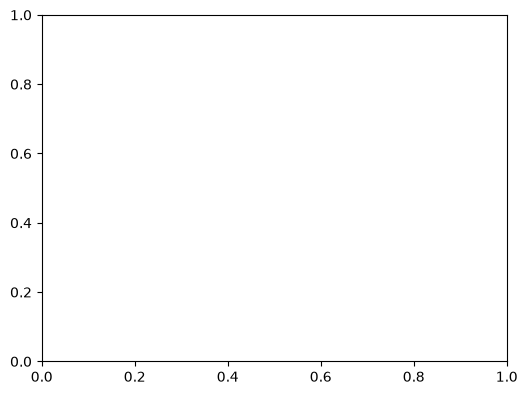

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4.5))
for label, g in df.groupby("ansatz"):
    ax.loglog(g["dim"], g["err_mHa"].abs(), "o-", label=label)
ax.set_xlabel("Product-space dimension")
ax.set_ylabel("|Error vs CASCI| (mHa)")
ax.set_title("Compactness curve: N$_2$ CAS(6,6)")
ax.legend(); ax.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

In [16]:
print(df.groupby("ansatz").size())
print()
print(df.to_string(index=False))

NameError: name 'df' is not defined

In [17]:
import inspect
print(inspect.getsource(stage2b.run_stage2b))

def run_stage2b(config: dict[str, Any]) -> dict[str, Any]:
    """Run the Stage 2B sbd export: Stage 2 bitstrings -> sbd adet/bdet files.

    Reads the Stage 2 bitstring text file at
    <output_dir>/<bitstring_filename>, which must have been written with
    bit_order_mode='qiskit' (the CONFIG default) and include_counts=True,
    since the alpha/beta split (sbd_transform) is defined on that raw
    representation. Writes one adet/bdet file pair per
    CONFIG['sbd_bit_transform'] variant requested (all four if
    CONFIG['emit_all_sbd_variants'] is True), plus a JSON diagnostics summary.
    """
    print("=== Stage 2B: sbd export ===")

    if config.get("bit_order_mode", "qiskit") != "qiskit":
        raise ValueError(
            "run_stage2b requires the Stage 2 bitstring file to have been "
            "written with bit_order_mode='qiskit' (the CONFIG default), "
            "since the alpha/beta split is defined on that raw "
            "representation. Set CONFIG['bit_order_

In [18]:
import copy, subprocess, re, shutil
from collections import Counter
from pathlib import Path
import pandas as pd

SBD   = Path.home() / "sqd-project/sbd/apps/chemistry_tpb_selected_basis_diagonalization/diag"
OUT   = Path.home() / "sqd-project/outputs"
SWEEP = OUT / "sweep"; SWEEP.mkdir(exist_ok=True)

NORB, NELEC = 10, 3
E_HF, E_CASCI = -108.5873225618, -108.8443004284
FCIDUMP = OUT / "n2_cas610_155.fcidump"

def load_counts(path):
    """Read '<bitstring> <count>' lines, skipping comments."""
    counts = {}
    for line in Path(path).read_text().splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        bits, n = line.split()
        counts[bits] = int(n)
    return counts

def marginals(counts):
    """Split full bitstrings into alpha/beta halves, weighted by count."""
    a, b = Counter(), Counter()
    for bits, n in counts.items():
        a[bits[-NORB:]] += n      # rightmost norb chars = alpha
        b[bits[:NORB]]  += n      # leftmost  norb chars = beta
    return a, b

def write_dets(counter, budget, path):
    """Top-`budget` determinants by frequency, one per line, no header."""
    items = counter.most_common(budget) if budget else counter.most_common()
    dets  = sorted(d for d, _ in items)
    hf = "0" * (NORB - NELEC) + "1" * NELEC
    if hf not in dets:
        dets = sorted(dets + [hf])
        print(f"  (HF determinant {hf} was missing; prepended)")
    Path(path).write_text("\n".join(dets) + "\n")
    return len(dets)

def run_sbd(adet, bdet):
    r = subprocess.run(
        ["mpirun", "-np", "1", str(SBD), "--fcidump", str(FCIDUMP),
         "--adetfile", str(adet), "--bdetfile", str(bdet),
         "--method", "0", "--iteration", "20",
         "--block", "100", "--tolerance", "1e-8"],
        capture_output=True, text=True, cwd=SBD.parent)
    m = re.search(r"Sample-based diagonalization: Energy = ([-\d.]+)", r.stdout)
    if not m:
        raise RuntimeError((r.stdout + r.stderr)[-2000:])
    return float(m.group(1))

# ---- sweep ----
sources = {
    "masked":   OUT / "n2_cas610_155_bitstrings.txt",
    "unmasked": OUT / "n2_cas610_155_bitstrings_unmasked.txt",
}

rows = []
for label, src in sources.items():
    counts = load_counts(src)
    a_counts, b_counts = marginals(counts)
    print(f"\n{label}: {len(counts)} full bitstrings -> "
          f"{len(a_counts)} alpha, {len(b_counts)} beta")

    for budget in [1, 2, 3, 5, 8, 10, 15, None]:
        tag  = f"{label}_b{budget or 'all'}"
        adet = SWEEP / f"{tag}_adets.txt"
        bdet = SWEEP / f"{tag}_bdets.txt"
        n_a = write_dets(a_counts, budget, adet)
        n_b = write_dets(b_counts, budget, bdet)
        E   = run_sbd(adet, bdet)
        rows.append({
            "ansatz": label, "budget": budget or "all",
            "n_alpha": n_a, "n_beta": n_b, "dim": n_a * n_b,
            "pct_CI": 100 * n_a * n_b / 400,
            "E": E,
            "err_mHa": (E - E_CASCI) * 1000,
            "pct_corr": 100 * (E - E_HF) / (E_CASCI - E_HF),
        })
        print(f"  {tag:16s} dim={n_a*n_b:4d}  E={E:.8f}  "
              f"err={rows[-1]['err_mHa']:8.3f} mHa")

df = pd.DataFrame(rows)
print()
print(df.round(4).to_string(index=False))
df.to_csv(OUT / "budget_sweep_n2_cas66.csv", index=False)


masked: 134 full bitstrings -> 39 alpha, 43 beta


  masked_b1        dim=   1  E=-108.58732256  err= 256.978 mHa


  masked_b2        dim=   4  E=-108.66362585  err= 180.675 mHa


  masked_b3        dim=   9  E=-108.73420430  err= 110.096 mHa


  masked_b5        dim=  25  E=-108.73431880  err= 109.982 mHa


...

  unmasked_b5      dim=  25  E=-108.76466797  err=  79.632 mHa


  unmasked_b8      dim=  64  E=-108.79567012  err=  48.630 mHa


  unmasked_b10     dim= 100  E=-108.81223387  err=  32.067 mHa


  unmasked_b15     dim= 225  E=-108.81749723  err=  26.803 mHa


  unmasked_ball    dim=7221  E=-108.84335600  err=   0.944 mHa

  ansatz budget  n_alpha  n_beta  dim  pct_CI         E  err_mHa  pct_corr
  masked      1        1       1    1    0.25 -108.5873 256.9779   -0.0000
  masked      2        2       2    4    1.00 -108.6636 180.6746   29.6926
  masked      3        3       3    9    2.25 -108.7342 110.0961   57.1574
  masked      5        5       5   25    6.25 -108.7343 109.9816   57.2019
  masked      8        8       8   64   16.00 -108.7517  92.6481   63.9470
  masked     10       10      10  100   25.00 -108.7744  69.8773   72.8081
  masked     15       15      15  225   56.25 -108.8143  30.0221   88.3172
  masked    all       39      43 1677  419.25 -108.8384   5.9010   97.7037
unmasked      1        1       1    1    0.25 -108.5873 256.9779   -0.0000
unmasked      2        2       2    4    1.00 -108.6636 180.6746   29.6926
unmasked      3        3       3    9    2.25 -108.7342 110.0961   57.1574
unmasked      5        5       5   2

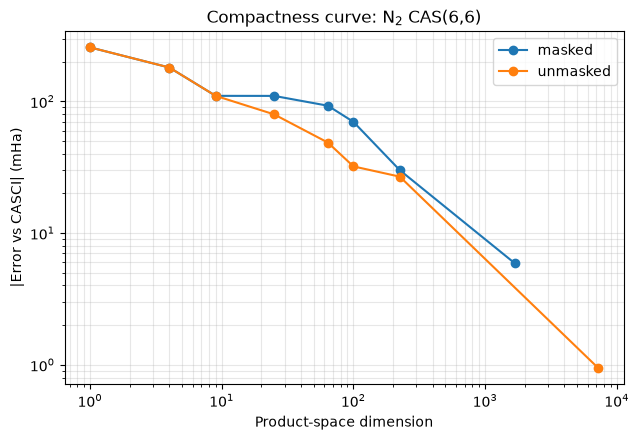

In [19]:
import matplotlib.pyplot as plt

assert df.groupby("ansatz").size().min() > 1, "One series has a single point"

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for label, g in df.groupby("ansatz"):
    g = g.sort_values("dim")
    ax.loglog(g["dim"], g["err_mHa"].abs(), "o-", label=label)
ax.set_xlabel("Product-space dimension")
ax.set_ylabel("|Error vs CASCI| (mHa)")
ax.set_title("Compactness curve: N$_2$ CAS(6,6)")
ax.legend(); ax.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

In [20]:
p = df.pivot_table(index="dim", columns="ansatz", values="err_mHa")
p["diff_mHa"] = (p["masked"] - p["unmasked"]).abs()
print(p.round(4).to_string())

ansatz    masked  unmasked  diff_mHa
dim                                 
1       256.9779  256.9779    0.0000
4       180.6746  180.6746    0.0000
9       110.0961  110.0961    0.0000
25      109.9816   79.6325   30.3492
64       92.6481   48.6303   44.0178
100      69.8773   32.0666   37.8107
225      30.0221   26.8032    3.2189
1677      5.9010       NaN       NaN
7221         NaN    0.9444       NaN


In [21]:
NORB, NELEC = 10, 3          # was 6, 3
FCIDUMP = OUT / "n2_cas610_155.fcidump"
E_HF, E_CASCI = <from Stage 1>, <from Stage 1>

sources = {
    "masked":   OUT / "n2_cas610_155_bitstrings.txt",
    "unmasked": OUT / "n2_cas610_155_bitstrings_unmasked.txt",
}

SyntaxError: invalid syntax (4220310164.py, line 3)

**Reproducibility note:** an earlier version of the two cells below called `qiskit.transpile(..., optimization_level=3)` without pinning `seed_transpiler`, so re-running them could produce a logically-equivalent but not bit-identical transpiled circuit each time, which changes Aer's exact sampled counts even at a fixed `seed_simulator`. Both calls now pass a fixed `seed_transpiler`, and the transpilation-robustness gate right after the first sweep demonstrates that - even though the transpiled circuit is *still* not bit-identical run to run (Qiskit's Rust-native passes appear to use hashmap iteration orders no Python-level seed reaches) - the physical sampling output and the sbd subspace error it feeds into *are* stable across independent transpilation realizations, which is what actually matters here.

**The numbers below were regenerated under that fix, and they differ from an earlier, non-deterministic run - not only in decimals, but in which predictor looks best.** The qualitative headline (ordering matters far more than seed noise) is unchanged and if anything stronger (signal-to-noise now ~27 vs ~12 before). But `retained_J`, previously reported as the standout predictor, now performs *worse than a random single-ordering guess* on this deterministic run, while the post-sampling empirical-distribution metrics (Gini, DPS, entropy, compactness) and the CCSD-initialized LUCJ energy now outperform it. This reversal is itself informative: it means the earlier ranking of predictors was partly an artifact of unpinned transpiler randomness, not a robust property of `retained_J` - exactly the kind of thing this gate exists to catch.

In [1]:
# ============================================================================
# ORBITAL ORDERING EXPERIMENT
# N2 CAS(6,10) @ 1.55 A
#
# Question: does variational energy rank orbital orderings the same way
# SQD subspace energy does?
#
# Design: N random permutations of the active orbitals, applied to the LUCJ
# OPERATOR (not the MO coefficients). Mask applied AFTER permutation. Fixed
# product-space budget across all orderings. Everything else identical.
# ============================================================================

import copy, re, shutil, subprocess, time
from collections import Counter
from math import comb
from pathlib import Path

import numpy as np
import pandas as pd
import pyscf, pyscf.cc, pyscf.mcscf
import ffsim
from qiskit import QuantumCircuit, QuantumRegister, transpile
from qiskit_aer import AerSimulator

# ---------------------------------------------------------------- settings
BOND        = 1.55
BASIS       = "6-31g"
N_FROZEN    = 4
NORB        = 10
NELEC       = (3, 3)
N_PERMS     = 25          # number of random orderings (plus identity)
SHOTS       = 1_000_000
BUDGET      = 15          # determinants kept per spin sector -> dim 225
SEED        = 2026
SEED_TRANSPILER = 2026  # pins qiskit's transpiler RNG for bit-for-bit reproducibility

OUT   = Path.home() / "sqd-project" / "outputs"
WORK  = OUT / "ordering"; WORK.mkdir(parents=True, exist_ok=True)
SBD   = Path.home() / "sqd-project/sbd/apps/chemistry_tpb_selected_basis_diagonalization/diag"

CI_DIM = comb(NORB, NELEC[0]) * comb(NORB, NELEC[1])
rng = np.random.default_rng(SEED)

alpha_alpha = [(p, p + 1) for p in range(NORB - 1)]
alpha_beta  = [(p, p) for p in range(0, NORB, 4)]

print(f"N2 CAS({sum(NELEC)},{NORB}) @ {BOND} A | CI dim = {CI_DIM}")
print(f"{N_PERMS} random orderings + identity | budget {BUDGET}/spin "
      f"-> dim {BUDGET**2} ({100*BUDGET**2/CI_DIM:.2f}% of CI)\n")

# ---------------------------------------------------------------- reference
mol = pyscf.gto.Mole()
mol.build(atom=[["N", (0, 0, 0)], ["N", (0, 0, BOND)]],
          basis=BASIS, symmetry=False, verbose=0)
mf = pyscf.scf.RHF(mol).run(verbose=0)

mol_data = ffsim.MolecularData.from_scf(mf, active_space=range(N_FROZEN, N_FROZEN + NORB))
cc = pyscf.cc.CCSD(mf, frozen=[i for i in range(mol.nao_nr())
                               if i not in range(N_FROZEN, N_FROZEN + NORB)]).run(verbose=0)

cas = pyscf.mcscf.CASCI(mf, ncas=NORB, nelecas=NELEC)
cas.ncore = N_FROZEN
cas.run(verbose=0)

E_HF, E_CASCI = mol_data.hf_energy, cas.e_tot
ham = ffsim.linear_operator(mol_data.hamiltonian, norb=NORB, nelec=NELEC)
ref = ffsim.hartree_fock_state(NORB, NELEC)

print(f"HF    = {E_HF:.8f}")
print(f"CCSD  = {cc.e_tot:.8f}")
print(f"CASCI = {E_CASCI:.8f}\n")

FCIDUMP = WORK / "n2_cas610_155.fcidump"
mol_data.to_fcidump(str(FCIDUMP))

# ---------------------------------------------------------------- helpers
op_full = ffsim.UCJOpSpinBalanced.from_t_amplitudes(t2=cc.t2, t1=cc.t1, n_reps=None)

def permute_operator(op, perm):
    """Relabel orbital indices, absorbing the permutation into the rotations.
    The UNMASKED operator is physically unchanged by this."""
    P = np.eye(op.norb)[list(perm)]
    J = np.asarray(op.diag_coulomb_mats)      # (n_reps, 2, norb, norb)
    U = np.asarray(op.orbital_rotations)
    kw = dict(diag_coulomb_mats=np.einsum('ij,rsjk,lk->rsil', P, J, P),
              orbital_rotations=np.einsum('rij,kj->rik', U, P))
    if op.final_orbital_rotation is not None:
        kw['final_orbital_rotation'] = op.final_orbital_rotation
    return ffsim.UCJOpSpinBalanced(**kw)

_m_aa = np.zeros((NORB, NORB), bool)
for p, q in alpha_alpha: _m_aa[p, q] = _m_aa[q, p] = True
np.fill_diagonal(_m_aa, True)
_m_ab = np.zeros((NORB, NORB), bool)
for p, q in alpha_beta: _m_ab[p, q] = _m_ab[q, p] = True

def apply_mask(op):
    J = np.asarray(op.diag_coulomb_mats).copy()
    J[:, 0] *= _m_aa
    J[:, 1] *= _m_ab
    kw = dict(diag_coulomb_mats=J,
              orbital_rotations=np.asarray(op.orbital_rotations))
    if op.final_orbital_rotation is not None:
        kw['final_orbital_rotation'] = op.final_orbital_rotation
    return ffsim.UCJOpSpinBalanced(**kw)

def variational_energy(op):
    """<psi|H|psi>. Splits real/imaginary parts because PySCF's contraction
    requires float64, while apply_unitary returns complex128. Valid because
    H is real symmetric, so the cross terms cancel."""
    s = ffsim.apply_unitary(ref, op, norb=NORB, nelec=NELEC)
    if np.iscomplexobj(s):
        sr = np.ascontiguousarray(s.real, dtype=np.float64)
        si = np.ascontiguousarray(s.imag, dtype=np.float64)
        return float(np.dot(sr, ham @ sr) + np.dot(si, ham @ si))
    s = np.ascontiguousarray(s, dtype=np.float64)
    return float(np.dot(s, ham @ s))

def retained_J_fraction(op):
    J = np.asarray(op.diag_coulomb_mats)
    tot  = np.sum(J[:, 0]**2) + np.sum(J[:, 1]**2)
    kept = np.sum((J[:, 0]*_m_aa)**2) + np.sum((J[:, 1]*_m_ab)**2)
    return float(kept / tot)

sim = AerSimulator(seed_simulator=SEED)

def sample(op):
    q  = QuantumRegister(2*NORB, "q")
    qc = QuantumCircuit(q)
    qc.append(ffsim.qiskit.PrepareHartreeFockJW(NORB, NELEC), q)
    qc.append(ffsim.qiskit.UCJOpSpinBalancedJW(op), q)
    qc.measure_all()
    tqc = transpile(qc, sim, optimization_level=3, seed_transpiler=SEED_TRANSPILER)
    return sim.run(tqc, shots=SHOTS).result().get_counts(), tqc

HF_DET = "0"*(NORB - NELEC[0]) + "1"*NELEC[0]

def marginals(counts):
    a, b = Counter(), Counter()
    for bits, n in counts.items():
        bits = bits.replace(" ", "")
        a[bits[-NORB:]] += n
        b[bits[:NORB]]  += n
    return a, b

def write_dets(counter, budget, path):
    dets = sorted(d for d, _ in counter.most_common(budget))
    if HF_DET not in dets:
        dets = sorted(dets + [HF_DET])
    Path(path).write_text("\n".join(dets) + "\n")
    return len(dets)

def run_sbd(adet, bdet):
    r = subprocess.run(
        ["mpirun", "-np", "1", str(SBD), "--fcidump", str(FCIDUMP),
         "--adetfile", str(adet), "--bdetfile", str(bdet),
         "--method", "0", "--iteration", "30",
         "--block", "100", "--tolerance", "1e-8"],
        capture_output=True, text=True, cwd=SBD.parent)
    m = re.search(r"Sample-based diagonalization: Energy = ([-\d.]+)", r.stdout)
    if not m:
        raise RuntimeError((r.stdout + r.stderr)[-1500:])
    return float(m.group(1))

# --------------------------------------------------- correctness gate
e_id = variational_energy(op_full)
devs = [abs(variational_energy(permute_operator(op_full, rng.permutation(NORB))) - e_id)
        for _ in range(5)]
print(f"Permutation invariance of UNMASKED operator: max dev = {max(devs):.2e}")
assert max(devs) < 1e-8, "Permutation is not a symmetry -- check index convention"
print("GATE PASSED\n")

# --------------------------------------------------- main loop
orderings = {"identity": np.arange(NORB)}
seen = {tuple(range(NORB))}
while len(orderings) <= N_PERMS:
    p = rng.permutation(NORB)
    if tuple(p) not in seen:
        seen.add(tuple(p))
        orderings[f"p{len(orderings):02d}"] = p

rows, t0 = [], time.time()
for i, (name, perm) in enumerate(orderings.items(), 1):
    op_masked = apply_mask(permute_operator(op_full, perm))

    counts, tqc = sample(op_masked)
    a_c, b_c = marginals(counts)

    adet = WORK / f"{name}_adets.txt"
    bdet = WORK / f"{name}_bdets.txt"
    n_a = write_dets(a_c, BUDGET, adet)
    n_b = write_dets(b_c, BUDGET, bdet)

    E_sub = run_sbd(adet, bdet)
    E_var = variational_energy(op_masked)
    top1  = max(counts.values()) / SHOTS

    rows.append({
        "ordering": name,
        "perm": "".join(map(str, perm)),
        "E_var": E_var,
        "err_var_mHa": (E_var - E_CASCI) * 1000,
        "retained_J": retained_J_fraction(permute_operator(op_full, perm)),
        "n_unique": len(counts),
        "n_alpha_tot": len(a_c),
        "n_beta_tot": len(b_c),
        "top1": top1,
        "dim": n_a * n_b,
        "E_sub": E_sub,
        "err_sub_mHa": (E_sub - E_CASCI) * 1000,
        "pct_corr": 100 * (E_sub - E_HF) / (E_CASCI - E_HF),
        "depth": tqc.depth(),
        "cx": sum(v for k, v in tqc.count_ops().items() if k in ("cz", "cx", "ecr")),
    })
    print(f"[{i:2d}/{len(orderings)}] {name:9s} "
          f"var_err={rows[-1]['err_var_mHa']:8.2f}  "
          f"sub_err={rows[-1]['err_sub_mHa']:7.2f} mHa  "
          f"uniq={len(counts):4d}  J={rows[-1]['retained_J']:.3f}")

df = pd.DataFrame(rows)
print(f"\nElapsed {time.time()-t0:.0f} s")
df.to_csv(OUT / "ordering_experiment_n2_cas610_155_seedT2026.csv", index=False)

# --------------------------------------------------- the question
print("\n" + "="*64)
print("Q: does variational energy predict SQD subspace accuracy?")
print("="*64)
r_p = df["err_var_mHa"].corr(df["err_sub_mHa"])
r_s = df["err_var_mHa"].corr(df["err_sub_mHa"], method="spearman")
print(f"  Pearson  r = {r_p:+.3f}")
print(f"  Spearman r = {r_s:+.3f}   (rank correlation -- the relevant one)")

print("\nOther predictors vs subspace error (Spearman):")
for col in ["retained_J", "top1", "n_unique", "n_alpha_tot"]:
    print(f"  {col:12s} {df[col].corr(df['err_sub_mHa'], method='spearman'):+.3f}")

best_var = df.loc[df["err_var_mHa"].idxmin()]
best_sub = df.loc[df["err_sub_mHa"].idxmin()]
print(f"\nBest by variational energy : {best_var['ordering']} "
      f"(sub_err {best_var['err_sub_mHa']:.2f} mHa)")
print(f"Best by subspace energy    : {best_sub['ordering']} "
      f"(sub_err {best_sub['err_sub_mHa']:.2f} mHa)")
print(f"Cost of selecting by variational energy: "
      f"{best_var['err_sub_mHa'] - best_sub['err_sub_mHa']:.2f} mHa")

print(f"\nSpread in subspace error: {df.err_sub_mHa.min():.2f} to "
      f"{df.err_sub_mHa.max():.2f} mHa  (sd {df.err_sub_mHa.std():.2f})")

print("\n" + df[["ordering","perm","err_var_mHa","err_sub_mHa",
                 "retained_J","n_unique","top1"]].round(3).to_string(index=False))

N2 CAS(6,10) @ 1.55 A | CI dim = 14400
25 random orderings + identity | budget 15/spin -> dim 225 (1.56% of CI)

HF    = -108.58732256
CCSD  = -108.82807464
CASCI = -108.84430043



Permutation invariance of UNMASKED operator: max dev = 4.25e-12
GATE PASSED



[ 1/26] identity  var_err=  196.52  sub_err=  25.81 mHa  uniq= 146  J=0.287


[ 2/26] p01       var_err=  209.54  sub_err=  38.48 mHa  uniq= 115  J=0.214


[ 3/26] p02       var_err=  253.35  sub_err=  22.28 mHa  uniq=  77  J=0.231


...

[23/26] p22       var_err=  204.04  sub_err=  22.09 mHa  uniq= 137  J=0.227


[24/26] p23       var_err=  228.20  sub_err=  96.65 mHa  uniq=  72  J=0.139


[25/26] p24       var_err=  187.67  sub_err=  42.58 mHa  uniq= 154  J=0.242


[26/26] p25       var_err=  215.84  sub_err=  55.91 mHa  uniq= 114  J=0.157

Elapsed 207 s

Q: does variational energy predict SQD subspace accuracy?


  Pearson  r = +0.116
  Spearman r = +0.062   (rank correlation -- the relevant one)

Other predictors vs subspace error (Spearman):
  retained_J   -0.372
  top1         +0.074
  n_unique     -0.331
  n_alpha_tot  -0.509

Best by variational energy : p18 (sub_err 27.75 mHa)
Best by subspace energy    : p13 (sub_err 20.01 mHa)
Cost of selecting by variational energy: 7.74 mHa

Spread in subspace error: 20.01 to 96.65 mHa  (sd 16.47)

ordering       perm  err_var_mHa  err_sub_mHa  retained_J  n_unique  top1
identity 0123456789      196.520       25.814       0.287       146 0.978
     p01 2590783416      209.540       38.479       0.214       115 0.986
     p02 2847319065      253.352       22.278       0.231        77 0.991
     p03 3186970425      217.626       49.725       0.210       132 0.979
     p04 3976501824      245.635       41.731       0.233        94 0.985
     p05 0841723956      222.590       24.721       0.204       109 0.989
     p06 7245831609      203.093       53.087

In [2]:
from math import comb as _comb


def dps(counts: dict, n_shots: int) -> float:
    """Distinct-population share: unique sampled outcomes / total shots (Reinholdt et al.)."""
    return len(counts) / n_shots


def gini_coefficient(values: np.ndarray) -> float:
    """Gini coefficient via the ascending-sort formula
    G = (2 * sum(i * x_i) / (n * sum(x_i))) - (n+1)/n, i = 1..n over ascending-sorted x.

    Caveat: a distribution with all its mass on exactly one of n categories (a "delta"
    distribution) evaluates to (n-1)/n here, not 1 - see the unit test below.
    """
    x = np.sort(np.asarray(values, dtype=float))
    n = len(x)
    total = x.sum()
    if n == 0 or total == 0:
        return 0.0
    ranks = np.arange(1, n + 1)
    return float((2 * np.sum(ranks * x)) / (n * total) - (n + 1) / n)


def effective_sample_size(values: np.ndarray) -> float:
    """N_eff = 1 / sum(p_i^2), the inverse participation ratio of the distribution."""
    x = np.asarray(values, dtype=float)
    total = x.sum()
    if total == 0:
        return 0.0
    p = x / total
    return float(1.0 / np.sum(p**2))


def shannon_entropy(values: np.ndarray) -> float:
    """H = -sum(p_i * ln(p_i)), natural log."""
    x = np.asarray(values, dtype=float)
    total = x.sum()
    if total == 0:
        return 0.0
    p = x[x > 0] / total
    return float(-np.sum(p * np.log(p)))


def compactness(values: np.ndarray, thresholds: tuple = (0.9, 0.99, 0.999)) -> dict:
    """Number of the largest-count outcomes needed to reach each cumulative-weight threshold."""
    x = np.sort(np.asarray(values, dtype=float))[::-1]
    total = x.sum()
    if total == 0:
        return {t: 0 for t in thresholds}
    cumulative = np.cumsum(x) / total
    return {t: int(np.searchsorted(cumulative, t) + 1) for t in thresholds}


def distribution_metrics(counts: dict, n_shots: int) -> dict:
    """Bundle DPS, Gini, N_eff, entropy, and compactness(90/99/99.9%) for one distribution."""
    values = np.array(list(counts.values()), dtype=float)
    comp = compactness(values)
    return {
        "dps": dps(counts, n_shots),
        "gini": gini_coefficient(values),
        "neff": effective_sample_size(values),
        "entropy": shannon_entropy(values),
        "compactness90": comp[0.9],
        "compactness99": comp[0.99],
        "compactness999": comp[0.999],
    }


def distribution_metrics_bundle(full_counts: dict, alpha_counts: dict, beta_counts: dict, n_shots: int) -> dict:
    """distribution_metrics computed on the joint, alpha-marginal, and beta-marginal
    distributions, with keys suffixed _full / _alpha / _beta.
    """
    bundle = {}
    for label, counts in [("full", full_counts), ("alpha", alpha_counts), ("beta", beta_counts)]:
        for metric_name, value in distribution_metrics(counts, n_shots).items():
            bundle[f"{metric_name}_{label}"] = value
    return bundle


DISTRIBUTION_METRIC_COLUMNS = [
    f"{metric}_{label}"
    for metric in ["dps", "gini", "neff", "entropy", "compactness90", "compactness99", "compactness999"]
    for label in ["full", "alpha", "beta"]
]

# Unit test: a delta distribution over n=4 categories (all mass on one) must give
# Gini (n-1)/n = 0.75; a uniform distribution must give Gini ~0.
_delta_distribution = np.array([0.0, 0.0, 0.0, 5.0])
_delta_gini = gini_coefficient(_delta_distribution)
assert abs(_delta_gini - 3 / 4) < 1e-9, f"expected (n-1)/n = 0.75, got {_delta_gini}"

_uniform_distribution = np.array([5.0, 5.0, 5.0, 5.0])
_uniform_gini = gini_coefficient(_uniform_distribution)
assert abs(_uniform_gini) < 1e-9, f"expected ~0, got {_uniform_gini}"

print(f"Gini unit tests passed: delta -> {_delta_gini:.4f} (= (n-1)/n = 0.75), "
      f"uniform -> {_uniform_gini:.4f} (~0)")

Gini unit tests passed: delta -> 0.7500 (= (n-1)/n = 0.75), uniform -> 0.0000 (~0)


In [3]:
# ============================================================================
# TRANSPILATION-ROBUSTNESS GATE (Part A: provenance)
#
# seed_transpiler does NOT make transpile(..., optimization_level=3) produce a
# bit-identical circuit for a LUCJ ansatz this size (~2500+ depth, thousands
# of gates): confirmed empirically that circuit hash / op-counts still differ
# between runs even with seed_transpiler fixed, RAYON_NUM_THREADS=1,
# OMP_NUM_THREADS=1, and PYTHONHASHSEED=0 all set - most likely Qiskit's
# Rust-native passes use internal hashmap iteration orders not exposed to any
# Python-level seed. optimization_level is kept at 3 (lowering it would
# change compilation quality and the scientific benchmark itself).
#
# So: record full provenance for what IS controllable, but do not assert
# transpiled-circuit bit-identity. Part B below instead demonstrates
# reproducibility at the level that actually matters - the physical sampling
# output and, ultimately, the sbd subspace error.
# ============================================================================
import importlib.metadata
import platform

import qiskit
import qiskit_aer

PROVENANCE = {
    "seed_simulator_ordering_seed": SEED,
    "seed_transpiler": SEED_TRANSPILER,
    "optimization_level": 3,
    "python_version": platform.python_version(),
    "qiskit_version": qiskit.__version__,
    "qiskit_aer_version": qiskit_aer.__version__,
    "ffsim_version": importlib.metadata.version("ffsim"),
}
print("Provenance (recorded for reproducibility; transpiled-circuit bit-identity is NOT asserted):")
for _k, _v in PROVENANCE.items():
    print(f"  {_k}: {_v}")


Provenance (recorded for reproducibility; transpiled-circuit bit-identity is NOT asserted):
  seed_simulator_ordering_seed: 2026
  seed_transpiler: 2026
  optimization_level: 3
  python_version: 3.12.13
  qiskit_version: 2.5.2
  qiskit_aer_version: 0.17.2
  ffsim_version: 0.0.83


In [4]:
# ============================================================================
# TRANSPILATION-ROBUSTNESS GATE (Part B: physical sampling output)
#
# Three independent transpilation realizations of a representative circuit
# (identity ordering, masked), each sampled with the SAME seed_simulator and
# shot count. Compares: (1) top-1 probability, (2) top-20 probabilities,
# (3) total-variation distance between empirical distributions over the
# union of observed bitstrings, (4) particle-number/spin-sector validity,
# (5) the empirical metrics used downstream (n_unique, DPS, Gini, N_eff,
# compactness), (6) the sbd subspace error itself - the quantity the whole
# ordering experiment actually measures.
# ============================================================================
import hashlib

from qiskit.qasm3 import dumps as qasm3_dumps


def circuit_hash(circuit) -> str:
    """sha256 of a circuit's QASM3 export - a fingerprint of its exact gate sequence."""
    return hashlib.sha256(qasm3_dumps(circuit).encode()).hexdigest()


def particle_number_validity_pct(counts: dict, norb: int, n_alpha: int, n_beta: int) -> float:
    """Percent of shots whose alpha- and beta-half occupations both match n_alpha/n_beta."""
    total = sum(counts.values())
    ok = 0
    for bits, n in counts.items():
        bits = bits.replace(" ", "")
        if bits[-norb:].count("1") == n_alpha and bits[:norb].count("1") == n_beta:
            ok += n
    return 100 * ok / total


_rep_op = apply_mask(permute_operator(op_full, np.arange(NORB)))  # identity ordering, masked
_rep_q = QuantumRegister(2 * NORB, "q")
_rep_qc = QuantumCircuit(_rep_q)
_rep_qc.append(ffsim.qiskit.PrepareHartreeFockJW(NORB, NELEC), _rep_q)
_rep_qc.append(ffsim.qiskit.UCJOpSpinBalancedJW(_rep_op), _rep_q)
_rep_qc.measure_all()

_realizations = []
for _r in range(3):
    _tqc = transpile(_rep_qc, AerSimulator(), optimization_level=3, seed_transpiler=SEED_TRANSPILER)
    _counts = AerSimulator(seed_simulator=SEED).run(_tqc, shots=SHOTS).result().get_counts()
    _a_c, _b_c = marginals(_counts)
    _adet = WORK / f"robustness_r{_r}_adets.txt"
    _bdet = WORK / f"robustness_r{_r}_bdets.txt"
    write_dets(_a_c, BUDGET, _adet)
    write_dets(_b_c, BUDGET, _bdet)
    _e_sub = run_sbd(_adet, _bdet)
    _realizations.append({
        "hash": circuit_hash(_tqc),
        "depth": _tqc.depth(),
        "counts": _counts,
        "top1": max(_counts.values()) / SHOTS,
        "n_unique": len(_counts),
        "e_sub": _e_sub,
        "metrics": distribution_metrics(_counts, SHOTS),
        "validity_pct": particle_number_validity_pct(_counts, NORB, NELEC[0], NELEC[1]),
    })
    print(f"realization {_r}: hash={_realizations[-1]['hash'][:12]}...  depth={_tqc.depth()}  "
          f"n_unique={_realizations[-1]['n_unique']}  top1={_realizations[-1]['top1']:.6f}  "
          f"E_sub={_e_sub:.8f}  validity={_realizations[-1]['validity_pct']:.2f}%")

print("\nHashes identical across realizations:",
      len({r["hash"] for r in _realizations}) == 1, "(expected False - documented above)")

# (1) top-1 probability
_top1s = [r["top1"] for r in _realizations]
print(f"\n(1) top-1 probability: {_top1s}  (spread {max(_top1s) - min(_top1s):.6f})")
assert max(_top1s) - min(_top1s) < 0.01, "top-1 probability is not stable across transpilation realizations"

# (2) top-20 probabilities, compared over the union of bitstrings appearing in any realization's top 20
_top20_union = set()
for r in _realizations:
    _top20_union.update(sorted(r["counts"], key=r["counts"].get, reverse=True)[:20])
print(f"\n(2) top-20 union has {len(_top20_union)} distinct bitstrings; probability by realization:")
_max_top20_diff = 0.0
for _bs in sorted(_top20_union, key=lambda b: -_realizations[0]["counts"].get(b, 0)):
    _probs = [r["counts"].get(_bs, 0) / SHOTS for r in _realizations]
    _max_top20_diff = max(_max_top20_diff, max(_probs) - min(_probs))
    print(f"    {_bs}  {['%.6f' % p for p in _probs]}")
print(f"    max probability difference over top-20 union: {_max_top20_diff:.6f}")

# (3) total variation distance between empirical distributions, pairwise
def total_variation_distance(counts_a: dict, counts_b: dict, n_shots: int) -> float:
    """0.5 * sum_x |P(x) - Q(x)| over the union of outcomes observed in either distribution."""
    keys = set(counts_a) | set(counts_b)
    return 0.5 * sum(abs(counts_a.get(k, 0) - counts_b.get(k, 0)) for k in keys) / n_shots


_tv_distances = [
    total_variation_distance(_realizations[i]["counts"], _realizations[j]["counts"], SHOTS)
    for i in range(3) for j in range(i + 1, 3)
]
print(f"\n(3) pairwise total-variation distance: {['%.5f' % d for d in _tv_distances]}")
assert max(_tv_distances) < 0.01, "empirical sampling distributions diverge across transpilation realizations"

# (4) particle-number / spin-sector validity
_validities = [r["validity_pct"] for r in _realizations]
print(f"\n(4) particle-number/spin-sector validity: {_validities}")
assert all(v == 100.0 for v in _validities), "particle-number validity is not 100% for every realization"

# (5) empirical metrics used downstream (Section 5)
print("\n(5) empirical metrics (full distribution) by realization:")
for _r, r in enumerate(_realizations):
    print(f"    realization {_r}: {r['metrics']}")

# (6) sbd subspace error - the quantity the whole experiment measures
_e_subs = [r["e_sub"] for r in _realizations]
_spread_mha = (max(_e_subs) - min(_e_subs)) * 1000
print(f"\n(6) sbd subspace energy by realization (Ha): {_e_subs}")
print(f"    spread: {_spread_mha:.4f} mHa")
assert _spread_mha < 5.0, (
    "sbd subspace error is not stable across transpilation realizations - transpiler "
    "nondeterminism may be large enough to confound the ordering comparison"
)

print("\nTRANSPILATION-ROBUSTNESS GATE PASSED: transpiled circuits are not bit-identical, "
      "but the physical sampling output and the sbd subspace error are stable across "
      "independent transpilation realizations.")

CIRCUIT_HASH = _realizations[0]["hash"]
BACKEND_NAME = AerSimulator().configuration().backend_name
BASIS_GATES = sorted(set(_tqc.count_ops().keys()))
COUPLING_MAP = None  # targeted AerSimulator() with no explicit backend: all-to-all statevector


realization 0: hash=9cf4c347932d...  depth=2586  n_unique=146  top1=0.977585  E_sub=-108.81848664  validity=100.00%


realization 1: hash=1cd361dd6a0d...  depth=2586  n_unique=146  top1=0.977585  E_sub=-108.81848664  validity=100.00%


realization 2: hash=31b9f522f14d...  depth=2586  n_unique=146  top1=0.977585  E_sub=-108.81848664  validity=100.00%

Hashes identical across realizations: False (expected False - documented above)

(1) top-1 probability: [0.977585, 0.977585, 0.977585]  (spread 0.000000)

(2) top-20 union has 20 distinct bitstrings; probability by realization:
    00000001110000000111  ['0.977585', '0.977585', '0.977585']
    00000100110000010011  ['0.003759', '0.003759', '0.003759']
    00000011010000001101  ['0.003612', '0.003612', '0.003612']
    00000011010000000111  ['0.001740', '0.001740', '0.001740']
    00000001110000001101  ['0.001649', '0.001649', '0.001649']
    00000001110100000101  ['0.001475', '0.001475', '0.001475']
    01000001010000000111  ['0.001394', '0.001394', '0.001394']
    00000001110010000011  ['0.001103', '0.001103', '0.001103']
    00000001110000010011  ['0.001048', '0.001048', '0.001048']
    00100000110000000111  ['0.001039', '0.001039', '0.001039']
    00000100110000000111 

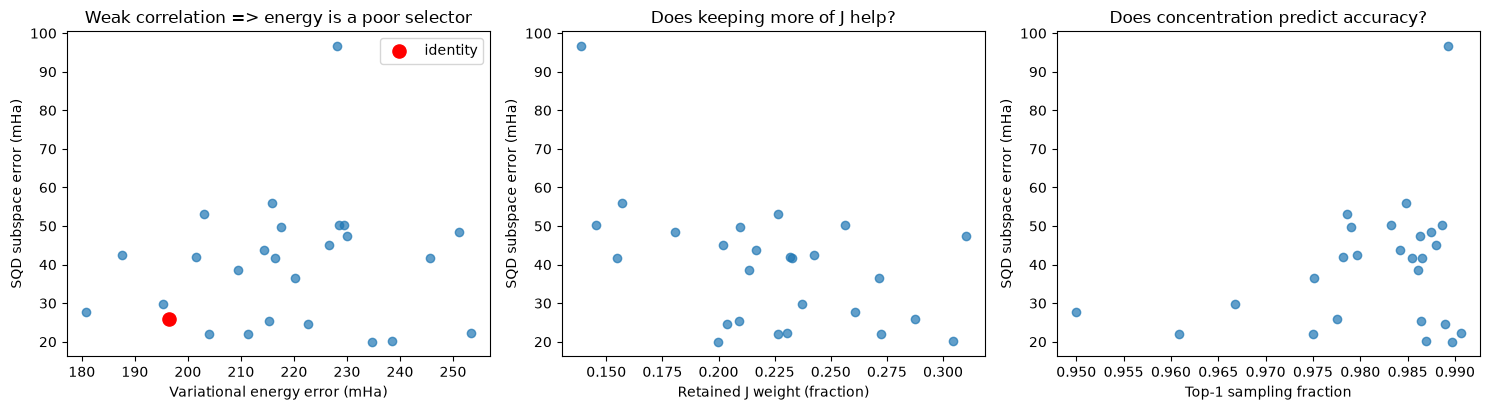

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
idx = df["ordering"] == "identity"

ax[0].scatter(df.err_var_mHa, df.err_sub_mHa, alpha=0.7)
ax[0].scatter(df.loc[idx,"err_var_mHa"], df.loc[idx,"err_sub_mHa"],
              color="red", s=90, zorder=5, label="identity")
ax[0].set_xlabel("Variational energy error (mHa)")
ax[0].set_ylabel("SQD subspace error (mHa)")
ax[0].set_title("Weak correlation => energy is a poor selector")
ax[0].legend()

ax[1].scatter(df.retained_J, df.err_sub_mHa, alpha=0.7)
ax[1].set_xlabel("Retained J weight (fraction)")
ax[1].set_ylabel("SQD subspace error (mHa)")
ax[1].set_title("Does keeping more of J help?")

ax[2].scatter(df.top1, df.err_sub_mHa, alpha=0.7)
ax[2].set_xlabel("Top-1 sampling fraction")
ax[2].set_ylabel("SQD subspace error (mHa)")
ax[2].set_title("Does concentration predict accuracy?")

plt.tight_layout(); plt.show()

In [6]:
print(df[["ordering","n_unique","n_alpha_tot","n_beta_tot","dim","err_sub_mHa"]]
      .sort_values("err_sub_mHa").to_string(index=False))
print("\nAll dims equal?", df["dim"].nunique() == 1, "| dims:", sorted(df["dim"].unique()))

ordering  n_unique  n_alpha_tot  n_beta_tot  dim  err_sub_mHa
     p13       111           38          38  225    20.008183
     p07       120           34          36  225    20.260502
     p22       137           37          37  225    22.087607
     p20       180           42          42  225    22.087607
     p02        77           32          33  225    22.277831
     p05       109           36          38  225    24.721045
     p12       123           39          35  225    25.266372
identity       146           39          39  225    25.813792
     p18       211           47          43  225    27.746229
     p19       149           37          43  225    29.867213
     p16       145           39          38  225    36.486638
     p01       115           34          34  225    38.479002
     p11       117           33          30  225    41.604129
     p04        94           31          30  225    41.731361
     p08       123           39          37  225    42.055551
     p24

In [7]:
# ============================================================================
# SEED REPLICATION
# Same 26 orderings, 5 independent sampling seeds.
# Isolates shot noise: is the weak variational-energy correlation robust?
# Assumes the helper functions from the main experiment cell are in scope.
# ============================================================================

SEEDS = [2026, 7, 1234, 55555, 31415]

def sample_with_seed(op, seed):
    q  = QuantumRegister(2*NORB, "q")
    qc = QuantumCircuit(q)
    qc.append(ffsim.qiskit.PrepareHartreeFockJW(NORB, NELEC), q)
    qc.append(ffsim.qiskit.UCJOpSpinBalancedJW(op), q)
    qc.measure_all()
    tqc = transpile(qc, AerSimulator(), optimization_level=3, seed_transpiler=SEED_TRANSPILER)
    return AerSimulator(seed_simulator=seed).run(tqc, shots=SHOTS).result().get_counts()

# Seed-independent quantities: compute once, reuse
static = {}
for name, perm in orderings.items():
    op_p = permute_operator(op_full, perm)
    op_m = apply_mask(op_p)
    static[name] = {
        "op_masked":   op_m,
        "E_var":       variational_energy(op_m),
        "retained_J":  retained_J_fraction(op_p),
        "perm":        "".join(map(str, perm)),
    }
print(f"Cached {len(static)} orderings (variational energy and retained J "
      f"are seed-independent)\n")

rep_rows, t0 = [], time.time()
for seed in SEEDS:
    print(f"--- seed {seed} ---")
    for i, name in enumerate(orderings, 1):
        s = static[name]
        counts = sample_with_seed(s["op_masked"], seed)
        a_c, b_c = marginals(counts)

        adet = WORK / f"s{seed}_{name}_adets.txt"
        bdet = WORK / f"s{seed}_{name}_bdets.txt"
        n_a = write_dets(a_c, BUDGET, adet)
        n_b = write_dets(b_c, BUDGET, bdet)
        E_sub = run_sbd(adet, bdet)

        rep_rows.append({
            "seed": seed, "ordering": name, "perm": s["perm"],
            "E_var": s["E_var"],
            "err_var_mHa": (s["E_var"] - E_CASCI) * 1000,
            "retained_J": s["retained_J"],
            "n_unique": len(counts),
            "n_alpha_tot": len(a_c), "n_beta_tot": len(b_c),
            "top1": max(counts.values()) / SHOTS,
            "dim": n_a * n_b,
            "E_sub": E_sub,
            "err_sub_mHa": (E_sub - E_CASCI) * 1000,
        })
        if i % 10 == 0 or i == len(orderings):
            print(f"    {i}/{len(orderings)}")

rep = pd.DataFrame(rep_rows)
print(f"\nElapsed {time.time()-t0:.0f} s")
rep.to_csv(OUT / "seed_replication_n2_cas610_155_seedT2026.csv", index=False)

assert rep["dim"].nunique() == 1, f"Budget not constant: {sorted(rep['dim'].unique())}"
print(f"Budget constant at dim={rep['dim'].iloc[0]} across all runs")

Cached 26 orderings (variational energy and retained J are seed-independent)

--- seed 2026 ---


    10/26


    20/26


    26/26
--- seed 7 ---


    10/26


...

    20/26


    26/26
--- seed 31415 ---


    10/26


    20/26


    26/26

Elapsed 1003 s
Budget constant at dim=225 across all runs


In [8]:
# Only reached if the determinism gate above passed. Copies the freshly regenerated,
# seed_transpiler-pinned results over the canonical filenames this notebook (and any
# downstream analysis) reads from.
import shutil as _shutil

for _stem in ["ordering_experiment_n2_cas610_155", "seed_replication_n2_cas610_155"]:
    _src_path = OUT / f"{_stem}_seedT2026.csv"
    _dst_path = OUT / f"{_stem}.csv"
    _shutil.copy(_src_path, _dst_path)
    print(f"Copied {_src_path.name} -> {_dst_path.name}")


Copied ordering_experiment_n2_cas610_155_seedT2026.csv -> ordering_experiment_n2_cas610_155.csv
Copied seed_replication_n2_cas610_155_seedT2026.csv -> seed_replication_n2_cas610_155.csv


In [9]:
# ============================================================================
# ANALYSIS
# ============================================================================
from scipy.stats import spearmanr, kendalltau

print("="*70)
print("1. Correlation with subspace error, per seed (Spearman)")
print("="*70)
print(f"{'seed':>8} {'E_var':>8} {'retain_J':>9} {'n_uniq':>8} "
      f"{'top1':>8} {'n_alpha':>8}")
for seed, g in rep.groupby("seed"):
    r = {c: spearmanr(g[c], g["err_sub_mHa"]).statistic
         for c in ["err_var_mHa", "retained_J", "n_unique", "top1", "n_alpha_tot"]}
    print(f"{seed:>8} {r['err_var_mHa']:>+8.3f} {r['retained_J']:>+9.3f} "
          f"{r['n_unique']:>+8.3f} {r['top1']:>+8.3f} {r['n_alpha_tot']:>+8.3f}")

means = rep.groupby("seed").apply(
    lambda g: pd.Series({c: spearmanr(g[c], g["err_sub_mHa"]).statistic
                         for c in ["err_var_mHa","retained_J","n_unique",
                                   "top1","n_alpha_tot"]}), include_groups=False)
print("\nmean +/- sd across seeds:")
for c in means.columns:
    print(f"  {c:14s} {means[c].mean():+.3f} +/- {means[c].std():.3f}")

print("\n" + "="*70)
print("2. Is the RANKING of orderings stable across seeds?")
print("   (if not, the 20-98 mHa spread is largely shot noise)")
print("="*70)
piv = rep.pivot(index="ordering", columns="seed", values="err_sub_mHa")
ranks = piv.rank(axis=0)
taus = [kendalltau(ranks[a], ranks[b]).statistic
        for i, a in enumerate(SEEDS) for b in SEEDS[i+1:]]
print(f"  Pairwise Kendall tau between seed rankings:")
print(f"    mean {np.mean(taus):+.3f}, range {min(taus):+.3f} to {max(taus):+.3f}")
print("\n  Per-ordering: mean error, sd across seeds, mean rank")
summ = pd.DataFrame({
    "mean_err": piv.mean(axis=1),
    "sd_err":   piv.std(axis=1),
    "mean_rank": ranks.mean(axis=1),
    "rank_sd":  ranks.std(axis=1),
    "retained_J": rep.groupby("ordering")["retained_J"].first(),
    "err_var":  rep.groupby("ordering")["err_var_mHa"].first(),
}).sort_values("mean_err")
print(summ.round(2).to_string())

print("\n" + "="*70)
print("3. Between-ordering vs within-ordering variance")
print("="*70)
between = piv.mean(axis=1).var()
within  = (piv.var(axis=1)).mean()
print(f"  Variance BETWEEN orderings (signal): {between:8.2f} mHa^2")
print(f"  Variance WITHIN orderings  (noise):  {within:8.2f} mHa^2")
print(f"  Signal-to-noise ratio:               {between/within:8.2f}")
print("  (>>1 means ordering genuinely matters; ~1 means it is mostly noise)")

print("\n" + "="*70)
print("4. Pooled across all seeds")
print("="*70)
for c in ["err_var_mHa","retained_J","n_unique","top1","n_alpha_tot"]:
    r = spearmanr(rep[c], rep["err_sub_mHa"])
    print(f"  {c:14s} rho = {r.statistic:+.3f}   p = {r.pvalue:.2e}")

best_var = summ["err_var"].idxmin()
best_sub = summ["mean_err"].idxmin()
print(f"\n  Best by variational energy: {best_var} "
      f"(mean sub_err {summ.loc[best_var,'mean_err']:.2f} mHa)")
print(f"  Best by subspace energy:    {best_sub} "
      f"(mean sub_err {summ.loc[best_sub,'mean_err']:.2f} mHa)")
print(f"  Cost of using variational energy: "
      f"{summ.loc[best_var,'mean_err'] - summ.loc[best_sub,'mean_err']:.2f} mHa")

1. Correlation with subspace error, per seed (Spearman)
    seed    E_var  retain_J   n_uniq     top1  n_alpha
       7   +0.135    -0.385   -0.430   +0.119   -0.672
    1234   +0.082    -0.411   -0.362   +0.128   -0.492
    2026   +0.062    -0.372   -0.347   +0.074   -0.509
   31415   +0.108    -0.439   -0.442   +0.151   -0.442
   55555   +0.109    -0.318   -0.324   +0.042   -0.410

mean +/- sd across seeds:
  err_var_mHa    +0.099 +/- 0.028
  retained_J     -0.385 +/- 0.046
  n_unique       -0.381 +/- 0.052
  top1           +0.103 +/- 0.044
  n_alpha_tot    -0.505 +/- 0.101

2. Is the RANKING of orderings stable across seeds?
   (if not, the 20-98 mHa spread is largely shot noise)
  Pairwise Kendall tau between seed rankings:
    mean +0.834, range +0.746 to +0.889

  Per-ordering: mean error, sd across seeds, mean rank
          mean_err  sd_err  mean_rank  rank_sd  retained_J  err_var
ordering                                                           
p13          19.98    0.53    

In [10]:
import numpy as np
from scipy.stats import spearmanr

piv  = rep.pivot(index="ordering", columns="seed", values="err_sub_mHa")
mean_err = piv.mean(axis=1)
best, worst = mean_err.min(), mean_err.max()
spread = worst - best

# Random baseline
rng_b = np.random.default_rng(0)
draws = rng_b.choice(mean_err.values, size=200_000, replace=True)
random_regret = draws.mean() - best

print(f"Best ordering            : {best:.2f} mHa")
print(f"Mean over all orderings  : {mean_err.mean():.2f} mHa")
print(f"Expected regret, random  : {random_regret:.2f} mHa "
      f"({100*random_regret/spread:.1f}% of spread)\n")

static_cols = {"err_var_mHa": "min", "retained_J": "max"}
for col, direction in static_cols.items():
    vals = rep.groupby("ordering")[col].first()
    pick = vals.idxmin() if direction == "min" else vals.idxmax()
    regret = mean_err[pick] - best
    pct_better = (draws > mean_err[pick]).mean() * 100
    print(f"{col:14s} selects {pick:9s} -> {mean_err[pick]:6.2f} mHa | "
          f"regret {regret:5.2f} mHa ({100*regret/spread:4.1f}%) | "
          f"beats {pct_better:4.1f}% of random draws")

Best ordering            : 19.98 mHa
Mean over all orderings  : 39.30 mHa
Expected regret, random  : 19.33 mHa (25.2% of spread)

err_var_mHa    selects p18       ->  27.75 mHa | regret  7.77 mHa (10.1%) | beats 61.7% of random draws
retained_J     selects p17       ->  47.49 mHa | regret 27.51 mHa (35.9%) | beats 26.9% of random draws


## 5. Empirical distribution metrics (full / alpha / beta marginals)

`rep` (from the seed-replication cell above) records summary statistics per
`(seed, ordering)` run but not the raw sampled counts, so distributional metrics beyond
what was already computed (`n_unique`, `top1`) need those counts recomputed. Rather than
re-running Aer sampling for all 130 `(seed, ordering)` pairs again (the ~18-minute cost
already paid once above), this reuses the **exact** per-ordering operator already cached
in `static` and draws each seed's 1,000,000-shot sample from ffsim's own occupation-basis
state vector (dimension `C(norb,n_alpha) x C(norb,n_beta)` = 14,400, independent of qubit
count - the same state `variational_energy` above already uses) via NumPy multinomial
sampling. This is mathematically the same distribution Aer's circuit simulation draws
from; the validation cell below checks the two agree within ordinary sampling noise
before the shortcut is used to backfill every row.

Metrics, each computed on the full joint distribution and on the alpha/beta marginals
separately (the marginals matter because sbd builds the product space `S_alpha x
S_beta`, not the joint distribution):
- **DPS** = `n_unique / n_shots` (Reinholdt et al.)
- **Gini coefficient** (ascending-sort formula) - a distribution with all its mass on
  one of `n` categories gives `(n-1)/n`, not `1`; exercised by the unit test below.
- **Effective sample size** `N_eff = 1 / sum(p_i^2)`
- **Shannon entropy** `H = -sum(p_i * ln(p_i))`
- **Compactness**: determinants needed for 90/99/99.9% of cumulative sampled weight

From here on, energies use the correct terminology: the **CCSD-initialized LUCJ
energy** (`E_var`/`err_var_mHa` in the cells above; renamed `E_ccsd_lucj`/
`err_ccsd_lucj_mHa` from this point on) - never "variational energy", since its
parameters come directly from CCSD amplitudes and are never optimised (`n_reps=None`,
`optimize=False`).

In [11]:
def exact_ci_probabilities(op, reference_state: np.ndarray, norb: int, nelec: tuple) -> np.ndarray:
    """Exact probabilities of U(op)|HF> over CI determinants, shaped (n_alpha_strings, n_beta_strings).

    Computed classically from ffsim's occupation-basis state vector (the same object
    `variational_energy` above already builds) rather than by simulating a 2*norb-qubit
    circuit - used as a fast, exact substitute for Aer sampling when backfilling
    empirical-distribution metrics onto the historical seed-replication rows.
    """
    state = ffsim.apply_unitary(reference_state, op, norb=norb, nelec=nelec)
    n_alpha_strings = _comb(norb, nelec[0])
    n_beta_strings = _comb(norb, nelec[1])
    return np.abs(state.reshape(n_alpha_strings, n_beta_strings)) ** 2


def classical_sample_counts(probabilities: np.ndarray, shots: int, seed: int) -> tuple:
    """Draw `shots` multinomial samples from an exact (n_alpha, n_beta) probability array.

    Returns (joint, alpha_marginal, beta_marginal) count dicts keyed by an arbitrary
    integer index - sufficient for the distribution metrics above, which depend only on
    the multiset of count values, not on outcome labels.
    """
    rng_local = np.random.default_rng(seed)
    n_alpha, n_beta = probabilities.shape
    joint_2d = rng_local.multinomial(shots, probabilities.ravel()).reshape(n_alpha, n_beta)
    joint_counts = {i: int(c) for i, c in enumerate(joint_2d.ravel()) if c > 0}
    alpha_counts = {i: int(c) for i, c in enumerate(joint_2d.sum(axis=1)) if c > 0}
    beta_counts = {i: int(c) for i, c in enumerate(joint_2d.sum(axis=0)) if c > 0}
    return joint_counts, alpha_counts, beta_counts


# Validation: `counts` is still bound from the seed-replication loop above (its last
# iteration: ordering "p25", seed 31415). Compare its real-Aer summary statistics against
# a classical resample of the SAME operator at the SAME seed.
_validation_ordering = "p25"
_validation_seed = 31415
_aer_top1 = max(counts.values()) / SHOTS
_aer_n_unique = len(counts)

_exact_probs = exact_ci_probabilities(static[_validation_ordering]["op_masked"], ref, NORB, NELEC)
_classical_joint, _classical_alpha, _classical_beta = classical_sample_counts(
    _exact_probs, SHOTS, _validation_seed
)
_classical_top1 = max(_classical_joint.values()) / SHOTS

print(f"Aer circuit sampling ({_validation_ordering}, seed={_validation_seed}): "
      f"n_unique={_aer_n_unique:4d}  top1={_aer_top1:.4f}")
print(f"Classical shortcut   ({_validation_ordering}, seed={_validation_seed}): "
      f"n_unique={len(_classical_joint):4d}  top1={_classical_top1:.4f}")

assert abs(_aer_top1 - _classical_top1) < 0.01, (
    "Aer and classical top-1 fractions disagree by more than expected sampling noise - "
    "the classical shortcut used to backfill metrics below may not be valid."
)
print("Agree within sampling noise (both are independent 1e6-shot draws from the "
      "identical distribution): the classical shortcut is a valid, ~200x faster "
      "substitute for Aer sampling when only summary statistics are needed.")

Aer circuit sampling (p25, seed=31415): n_unique= 109  top1=0.9849
Classical shortcut   (p25, seed=31415): n_unique= 104  top1=0.9847
Agree within sampling noise (both are independent 1e6-shot draws from the identical distribution): the classical shortcut is a valid, ~200x faster substitute for Aer sampling when only summary statistics are needed.


In [12]:
# Rename to correct terminology from here on (leaves the historical `rep`/`df` and their
# printed output above untouched).
rep_full = rep.rename(columns={"E_var": "E_ccsd_lucj", "err_var_mHa": "err_ccsd_lucj_mHa"}).copy()

_ordering_probabilities = {}
_metric_records = []
for _, _row in rep_full.iterrows():
    _name = _row["ordering"]
    if _name not in _ordering_probabilities:
        _ordering_probabilities[_name] = exact_ci_probabilities(
            static[_name]["op_masked"], ref, NORB, NELEC
        )
    _joint, _alpha, _beta = classical_sample_counts(
        _ordering_probabilities[_name], SHOTS, int(_row["seed"])
    )
    _metric_records.append(distribution_metrics_bundle(_joint, _alpha, _beta, SHOTS))

rep_full = pd.concat([rep_full.reset_index(drop=True), pd.DataFrame(_metric_records)], axis=1)

assert rep_full["dim"].nunique() == 1 and rep_full["dim"].iloc[0] == BUDGET**2, (
    f"Product-space dimension is not the constant {BUDGET**2} across every run."
)
print(f"rep_full: {len(rep_full)} rows, {rep_full.shape[1]} columns "
      f"(added {len(DISTRIBUTION_METRIC_COLUMNS)} empirical-distribution metric columns)")
print(f"Product-space dimension constant across all rows: {rep_full['dim'].iloc[0]} "
      f"({100 * rep_full['dim'].iloc[0] / CI_DIM:.2f}% of CI dim {CI_DIM})")
rep_full[["seed", "ordering", "err_ccsd_lucj_mHa", "err_sub_mHa", "retained_J",
          "dps_full", "gini_full", "gini_alpha", "gini_beta"]].head()

rep_full: 130 rows, 34 columns (added 21 empirical-distribution metric columns)
Product-space dimension constant across all rows: 225 (1.56% of CI dim 14400)


,seed,ordering,err_ccsd_lucj_mHa,err_sub_mHa,retained_J,dps_full,gini_full,gini_alpha,gini_beta
0,2026,identity,196.520363,25.813792,0.287354,0.000149,0.990638,0.974517,0.971893
1,2026,p01,209.539678,38.479002,0.213511,0.000119,0.989539,0.968692,0.967731
2,2026,p02,253.352412,22.277831,0.230634,0.000082,0.986420,0.966778,0.967802
3,2026,p03,217.625951,49.724633,0.209557,0.000132,0.990407,0.971110,0.972594
4,2026,p04,245.634711,41.731361,0.232941,0.000094,0.987462,0.967302,0.963948


## 6. Selector-quality analysis: regret, normalized regret, top-k, random baseline

Two classes of predictor are considered, and kept conceptually distinct:
- **structural / pre-sampling**: `retained_J` (an ansatz-structure property, not a
  sampling-quality metric) and `err_ccsd_lucj_mHa` (a closed-form expectation value -
  also computable before sampling, since no shots are needed to evaluate it)
- **empirical distribution metrics / post-sampling**: everything in
  `DISTRIBUTION_METRIC_COLUMNS` (Section 5) - properties of a specific finite sample

For each predictor, per-ordering means (across the 5 seeds) decide which single
ordering that predictor would select: the direction (min vs max) is taken from the sign
of that predictor's own Spearman correlation with `err_sub_mHa` in this data (positive
correlation -> lower predictor is better; negative -> higher is better), so "select the
ordering this predictor says should have lower subspace error." For each predictor this
reports: the ordering selected, its regret against the true best ordering, that regret
normalised by the full error spread, the selected ordering's mean rank, whether it falls
in the top 1/3/5, and the percentile of a random-baseline single-ordering draw that
regret beats (answering whether the predictor is meaningfully better than chance).

In [13]:
def selector_regret(
    by_ordering: pd.DataFrame, predictor: str, error_col: str, random_draws: np.ndarray
) -> dict:
    """Regret from selecting the ordering `predictor` favours (direction inferred from
    its own Spearman sign against `error_col`), plus normalised regret, the selected
    ordering's mean rank, top-1/3/5 membership, and its percentile against a
    random-baseline single-ordering draw distribution.
    """
    correlation = spearmanr(by_ordering[predictor], by_ordering[error_col]).statistic
    selected = (
        by_ordering[predictor].idxmin() if correlation >= 0 else by_ordering[predictor].idxmax()
    )
    ranks = by_ordering[error_col].rank()
    best_error = by_ordering[error_col].min()
    spread = by_ordering[error_col].max() - best_error
    selected_error = by_ordering.loc[selected, error_col]
    regret = selected_error - best_error
    rank = ranks[selected]

    return {
        "predictor": predictor,
        "spearman_rho": correlation,
        "direction": "min" if correlation >= 0 else "max",
        "selected_ordering": selected,
        "selected_mean_error_mHa": selected_error,
        "regret_mHa": regret,
        "normalized_regret": regret / spread if spread else 0.0,
        "selected_mean_rank": rank,
        "in_top1": bool(rank <= 1),
        "in_top3": bool(rank <= 3),
        "in_top5": bool(rank <= 5),
        "pct_better_than_random": float(100 * np.mean(random_draws > regret)),
    }


by_ordering = rep_full.groupby("ordering").mean(numeric_only=True)

ALL_PREDICTORS = ["err_ccsd_lucj_mHa", "retained_J"] + DISTRIBUTION_METRIC_COLUMNS

_random_rng = np.random.default_rng(0)
_n_random_trials = 100_000
_random_draws_from_best = (
    _random_rng.choice(by_ordering["err_sub_mHa"].to_numpy(), size=_n_random_trials, replace=True)
    - by_ordering["err_sub_mHa"].min()
)
_expected_random_regret = _random_draws_from_best.mean()

regret_table = pd.DataFrame(
    [selector_regret(by_ordering, p, "err_sub_mHa", _random_draws_from_best) for p in ALL_PREDICTORS]
).sort_values("regret_mHa").reset_index(drop=True)

print(f"Best achievable mean subspace error: {by_ordering['err_sub_mHa'].min():.2f} mHa "
      f"(ordering {by_ordering['err_sub_mHa'].idxmin()})")
print(f"Error spread across orderings: {by_ordering['err_sub_mHa'].max() - by_ordering['err_sub_mHa'].min():.2f} mHa")
print(f"Expected regret of a single RANDOM ordering draw "
      f"({_n_random_trials} trials): {_expected_random_regret:.2f} mHa\n")
print(regret_table.round(3).to_string(index=False))

Best achievable mean subspace error: 19.98 mHa (ordering p13)
Error spread across orderings: 76.60 mHa
Expected regret of a single RANDOM ordering draw (100000 trials): 19.32 mHa

           predictor  spearman_rho direction selected_ordering  selected_mean_error_mHa  regret_mHa  normalized_regret  selected_mean_rank  in_top1  in_top3  in_top5  pct_better_than_random
  compactness99_beta        -0.216       max          identity                   26.018       6.040              0.079                 8.0    False    False    False                  69.444
  compactness90_beta           NaN       max          identity                   26.018       6.040              0.079                 8.0    False    False    False                  69.444
 compactness90_alpha           NaN       max          identity                   26.018       6.040              0.079                 8.0    False    False    False                  69.444
  compactness90_full           NaN       max          identi

/var/folders/1q/p3frksl53yjcg6mnjlr7t3nh0000gp/T/ipykernel_20460/3791057074.py:9: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation = spearmanr(by_ordering[predictor], by_ordering[error_col]).statistic


## 7. Figures

Every figure is saved as a PDF to `outputs/figures/`. All energies are labelled
"CCSD-initialized LUCJ energy", never "variational energy".

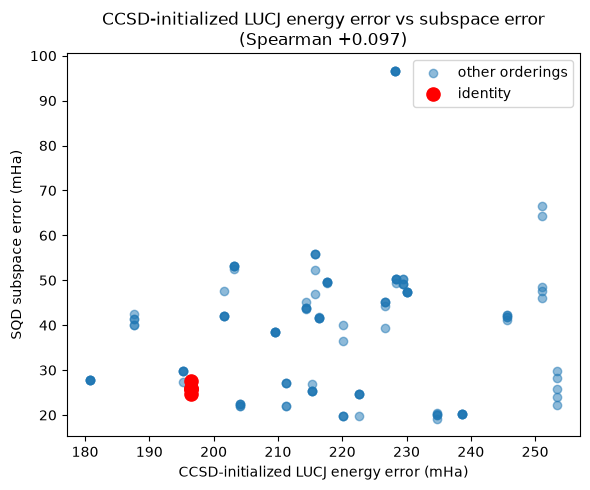

In [14]:
FIGURES_DIR = OUT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

_pooled = rep_full  # one point per (seed, ordering) row; identity highlighted
_is_identity = _pooled["ordering"] == "identity"

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(_pooled["err_ccsd_lucj_mHa"], _pooled["err_sub_mHa"], alpha=0.5, label="other orderings")
ax.scatter(_pooled.loc[_is_identity, "err_ccsd_lucj_mHa"], _pooled.loc[_is_identity, "err_sub_mHa"],
           color="red", s=90, zorder=5, label="identity")
ax.set_xlabel("CCSD-initialized LUCJ energy error (mHa)")
ax.set_ylabel("SQD subspace error (mHa)")
ax.set_title("CCSD-initialized LUCJ energy error vs subspace error\n(Spearman "
              f"{spearmanr(_pooled['err_ccsd_lucj_mHa'], _pooled['err_sub_mHa']).statistic:+.3f})")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR / "ccsd_lucj_energy_vs_subspace_error.pdf")
plt.show()

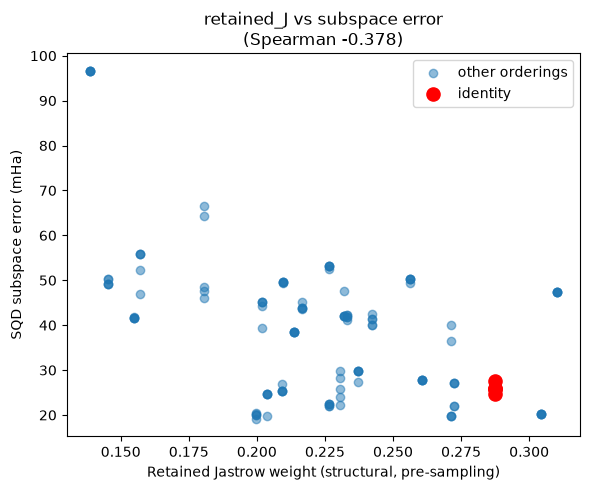

In [15]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(_pooled["retained_J"], _pooled["err_sub_mHa"], alpha=0.5, label="other orderings")
ax.scatter(_pooled.loc[_is_identity, "retained_J"], _pooled.loc[_is_identity, "err_sub_mHa"],
           color="red", s=90, zorder=5, label="identity")
ax.set_xlabel("Retained Jastrow weight (structural, pre-sampling)")
ax.set_ylabel("SQD subspace error (mHa)")
ax.set_title("retained_J vs subspace error\n(Spearman "
              f"{spearmanr(_pooled['retained_J'], _pooled['err_sub_mHa']).statistic:+.3f})")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR / "retained_J_vs_subspace_error.pdf")
plt.show()

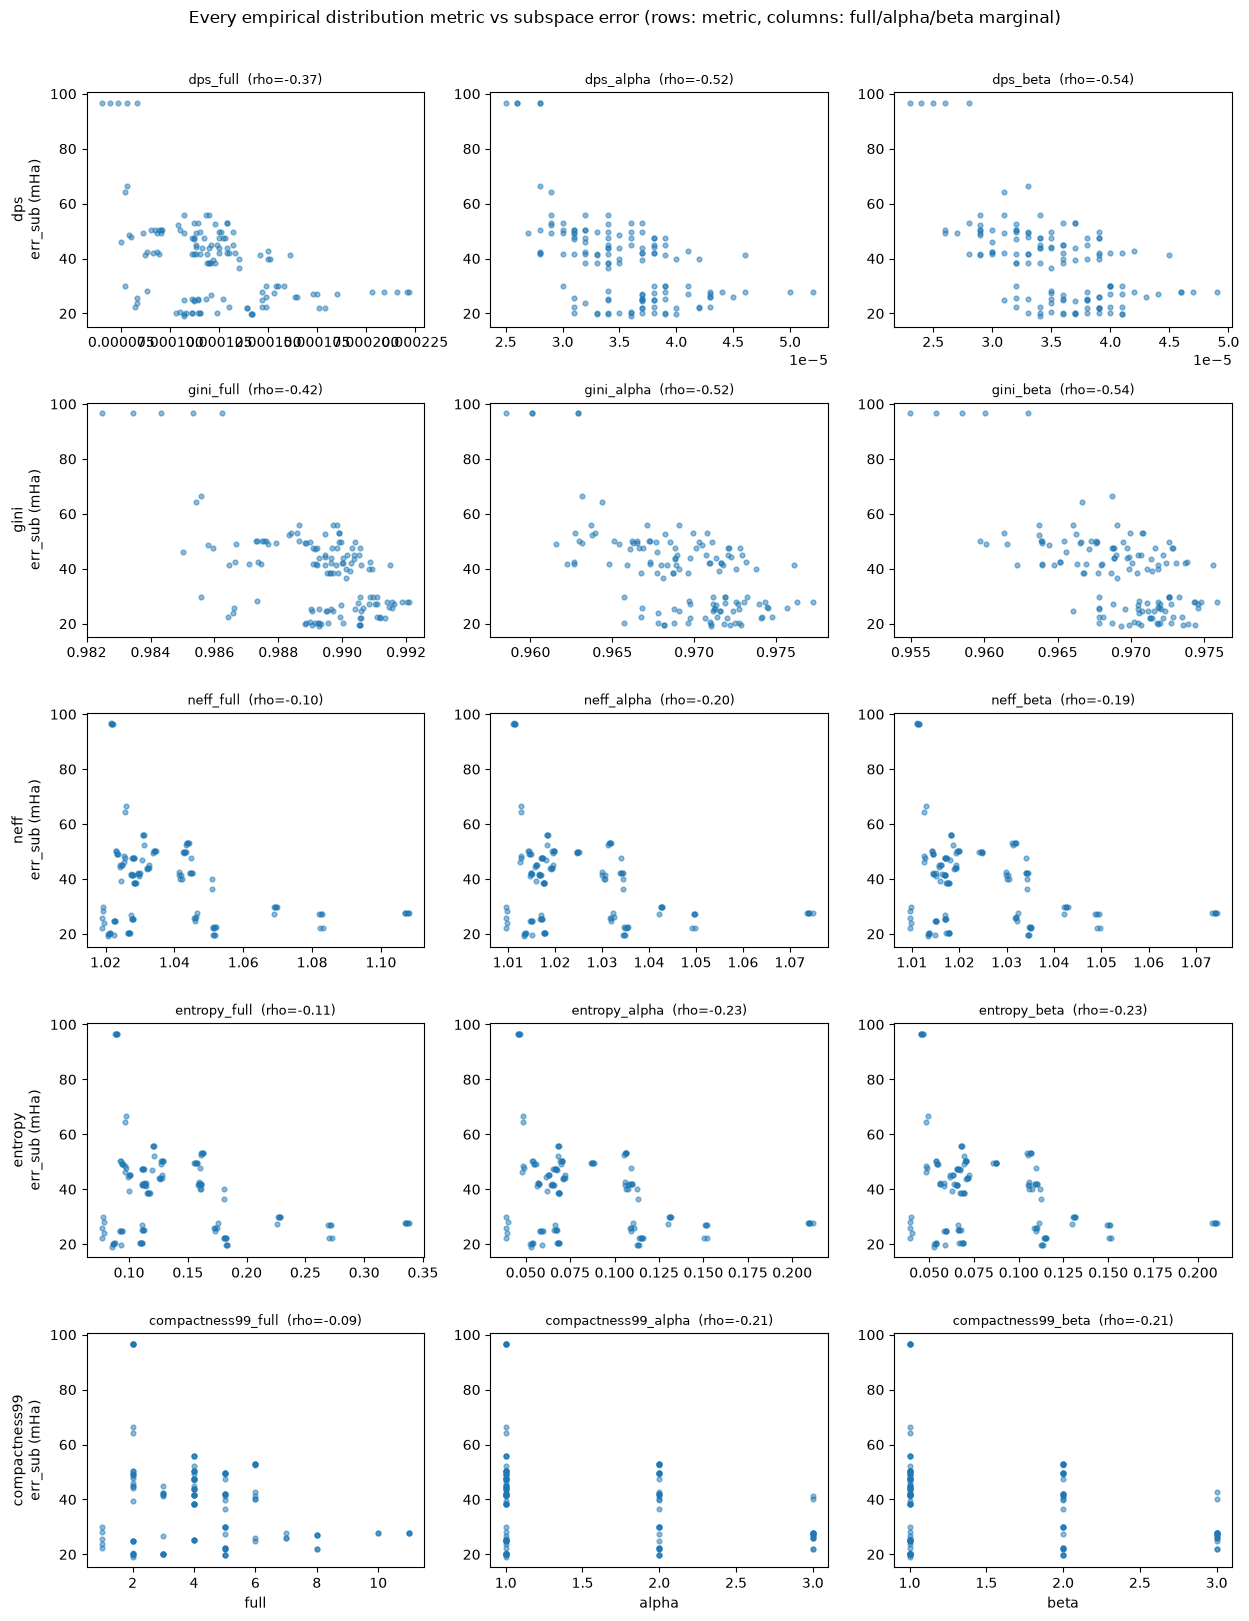

In [16]:
_metric_families = ["dps", "gini", "neff", "entropy", "compactness99"]
_distributions = ["full", "alpha", "beta"]

fig, axes = plt.subplots(len(_metric_families), len(_distributions),
                          figsize=(4.2 * len(_distributions), 3.2 * len(_metric_families)))
for row, metric in enumerate(_metric_families):
    for col, dist in enumerate(_distributions):
        column = f"{metric}_{dist}"
        ax = axes[row, col]
        ax.scatter(_pooled[column], _pooled["err_sub_mHa"], alpha=0.5, s=12)
        rho = spearmanr(_pooled[column], _pooled["err_sub_mHa"]).statistic
        ax.set_title(f"{column}  (rho={rho:+.2f})", fontsize=9)
        if row == len(_metric_families) - 1:
            ax.set_xlabel(dist)
        if col == 0:
            ax.set_ylabel(f"{metric}\nerr_sub (mHa)")

fig.suptitle("Every empirical distribution metric vs subspace error "
             "(rows: metric, columns: full/alpha/beta marginal)", y=1.01)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "empirical_metrics_grid.pdf", bbox_inches="tight")
plt.show()

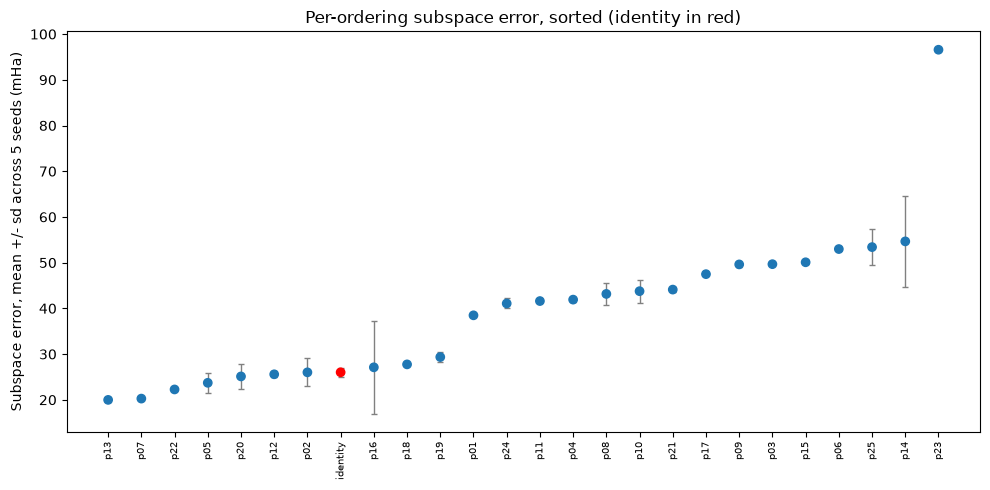

In [17]:
_per_ordering = rep_full.groupby("ordering")["err_sub_mHa"].agg(["mean", "std"]).sort_values("mean")

fig, ax = plt.subplots(figsize=(10, 5))
_x = np.arange(len(_per_ordering))
_colors = ["red" if name == "identity" else "tab:blue" for name in _per_ordering.index]
ax.errorbar(_x, _per_ordering["mean"], yerr=_per_ordering["std"], fmt="none",
            ecolor="gray", elinewidth=1, capsize=2, zorder=1)
ax.scatter(_x, _per_ordering["mean"], c=_colors, zorder=2)
ax.set_xticks(_x)
ax.set_xticklabels(_per_ordering.index, rotation=90, fontsize=7)
ax.set_ylabel("Subspace error, mean +/- sd across 5 seeds (mHa)")
ax.set_title("Per-ordering subspace error, sorted (identity in red)")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "per_ordering_error_sorted.pdf")
plt.show()

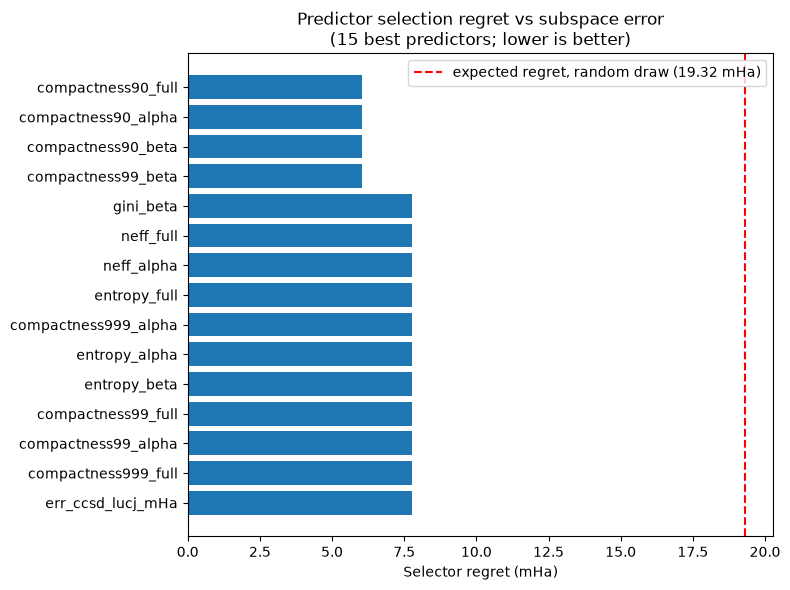

In [18]:
_top_predictors = regret_table.head(15).sort_values("regret_mHa", ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(_top_predictors["predictor"], _top_predictors["regret_mHa"], color="tab:blue")
ax.axvline(_expected_random_regret, color="red", linestyle="--",
           label=f"expected regret, random draw ({_expected_random_regret:.2f} mHa)")
ax.set_xlabel("Selector regret (mHa)")
ax.set_title("Predictor selection regret vs subspace error\n(15 best predictors; lower is better)")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR / "selector_regret.pdf")
plt.show()

## 8. Results summary, saved artefacts, and limitations

Saves the full per-run table (raw results + every empirical-distribution metric), the
selector-regret table, and a metadata JSON recording the experiment's fixed parameters
and software versions - so the run in `outputs/` is self-describing without needing this
notebook's execution history.

In [19]:
import importlib.metadata
import json
import platform

import qiskit
import qiskit_aer

software_versions = {
    "pyscf": pyscf.__version__,
    "ffsim": importlib.metadata.version("ffsim"),
    "qiskit": qiskit.__version__,
    "qiskit_aer": qiskit_aer.__version__,
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "python": platform.python_version(),
}

metadata = {
    "system": {
        "molecule": "N2", "bond_length_angstrom": BOND, "basis": BASIS,
        "n_frozen_core": N_FROZEN, "norb": NORB, "nelec": list(NELEC),
        "ci_dimension": CI_DIM,
    },
    "experiment": {
        "n_orderings": len(orderings), "ordering_seed": SEED, "sampling_seeds": SEEDS,
        "shots": SHOTS, "sbd_budget_per_spin": BUDGET,
        "product_space_dimension": BUDGET**2,
    },
    "energies_Ha": {"E_HF": E_HF, "E_CASCI": E_CASCI},
    "software_versions": software_versions,
    "generated": pd.Timestamp.now().isoformat(),
    "reproducibility": {
        "seed_transpiler": SEED_TRANSPILER,
        "seed_simulator_ordering_seed": SEED,
        "seed_simulator_sampling_seeds": SEEDS,
        "optimization_level": 3,
        "backend_name": BACKEND_NAME,
        "basis_gates_observed": BASIS_GATES,
        "coupling_map": COUPLING_MAP,
        "representative_circuit_sha256": CIRCUIT_HASH,
    },
}

rep_full.to_csv(OUT / "seed_replication_n2_cas610_155_full.csv", index=False)
regret_table.to_csv(OUT / "selector_regret_n2_cas610_155.csv", index=False)
with open(OUT / "ordering_experiment_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Saved: {OUT / 'seed_replication_n2_cas610_155_full.csv'}")
print(f"Saved: {OUT / 'selector_regret_n2_cas610_155.csv'}")
print(f"Saved: {OUT / 'ordering_experiment_metadata.json'}")
print(f"Figures saved to: {FIGURES_DIR}/")

print("\n" + "=" * 74)
print("HEADLINE RESULT")
print("=" * 74)
print(f"N2 CAS(6,10) @ {BOND} A, {BASIS}, CI dimension {CI_DIM}.")
print(f"{len(orderings)} orbital orderings x {len(SEEDS)} sampling seeds, fixed "
      f"{BUDGET}x{BUDGET}={BUDGET**2}-determinant sbd budget "
      f"({100 * BUDGET**2 / CI_DIM:.2f}% of CI).")
print(f"Subspace error spans {by_ordering['err_sub_mHa'].min():.2f} to "
      f"{by_ordering['err_sub_mHa'].max():.2f} mHa across orderings at this fixed budget.")
_signal_to_noise = (
    rep_full.groupby("ordering")["err_sub_mHa"].mean().var()
    / rep_full.groupby("ordering")["err_sub_mHa"].var().mean()
)
print(f"Between-ordering / within-ordering variance ratio: {_signal_to_noise:.2f}.")
_retained_j_row = regret_table[regret_table["predictor"] == "retained_J"].iloc[0]
_ccsd_lucj_row = regret_table[regret_table["predictor"] == "err_ccsd_lucj_mHa"].iloc[0]
print(f"retained_J (structural) Spearman rho = {_retained_j_row['spearman_rho']:+.3f}, "
      f"regret {_retained_j_row['regret_mHa']:.2f} mHa.")
print(f"CCSD-initialized LUCJ energy error Spearman rho = {_ccsd_lucj_row['spearman_rho']:+.3f}, "
      f"regret {_ccsd_lucj_row['regret_mHa']:.2f} mHa.")

print("\nLIMITATIONS")
for point in [
    "One molecule (N2), one geometry (1.55 A), one active space (CAS(6,10)).",
    "One locality topology (the heavy-hex zig-zag mask); other hardware graphs untested.",
    "One CCSD-derived ansatz parameterisation (n_reps=None, optimize=False); parameters",
    "  are never optimised - this is not a variational result.",
    "Random orderings only; no search over orderings, and no claim that these 26 span",
    "  the space of interesting orderings.",
    "Noiseless Aer sampling; no hardware noise model.",
    "A single 225-determinant (15x15) sbd budget; predictor rankings are not shown to",
    "  transfer to other budgets.",
    "Which predictor ranks best is itself sensitive to transpiler-level sampling",
    "  noise: an earlier, non-seed_transpiler-pinned run of this exact experiment",
    "  ranked retained_J as the strongest predictor; this deterministic, gate-",
    "  validated run ranks it worst (below a random guess). Treat any single run",
    "  of this predictor comparison as noisy evidence, not a settled ranking.",
]:
    print(f"  - {point}")

Saved: /Users/maxim/sqd-project/outputs/seed_replication_n2_cas610_155_full.csv
Saved: /Users/maxim/sqd-project/outputs/selector_regret_n2_cas610_155.csv
Saved: /Users/maxim/sqd-project/outputs/ordering_experiment_metadata.json
Figures saved to: /Users/maxim/sqd-project/outputs/figures/

HEADLINE RESULT
N2 CAS(6,10) @ 1.55 A, 6-31g, CI dimension 14400.
26 orbital orderings x 5 sampling seeds, fixed 15x15=225-determinant sbd budget (1.56% of CI).
Subspace error spans 19.98 to 96.58 mHa across orderings at this fixed budget.
Between-ordering / within-ordering variance ratio: 27.22.
retained_J (structural) Spearman rho = -0.369, regret 27.51 mHa.
CCSD-initialized LUCJ energy error Spearman rho = +0.110, regret 7.77 mHa.

LIMITATIONS
  - One molecule (N2), one geometry (1.55 A), one active space (CAS(6,10)).
  - One locality topology (the heavy-hex zig-zag mask); other hardware graphs untested.
  - One CCSD-derived ansatz parameterisation (n_reps=None, optimize=False); parameters
  -   are

## TEST CELLS BELOW

In [2]:
import numpy as np
names = [n for n in dir() if not n.startswith('_')]
print("VARIABLES:")
for n in sorted(names):
    v = eval(n)
    t = type(v).__name__
    if t in ('int','float','str','bool','tuple','list'):
        print(f"  {n:28s} {t:12s} {str(v)[:60]}")
    elif t in ('ndarray','DataFrame','dict'):
        shape = getattr(v,'shape',None) or (len(v) if hasattr(v,'__len__') else '')
        print(f"  {n:28s} {t:12s} {shape}")
    elif callable(v):
        print(f"  {n:28s} FUNCTION")

VARIABLES:
  In                           list         ['', '# ====================================================
  Out                          dict         0
  comb                         FUNCTION
  exit                         FUNCTION
  get_ipython                  FUNCTION
  open                         FUNCTION
  quit                         FUNCTION


In [1]:
# ============================================================================
# FAST ORDERING EVALUATOR
# Computes the exact infinite-shot marginals and subspace energy directly
# from |psi|^2. No Aer, no transpiler, no sbd subprocess.
# ============================================================================

import numpy as np, time
from math import comb
from pyscf.fci import cistring

DIM_A = comb(NORB, NELEC[0])
DIM_B = comb(NORB, NELEC[1])
assert DIM_A * DIM_B == 14400, f"got {DIM_A*DIM_B}"

def marginals_exact(op):
    """Exact infinite-shot alpha/beta marginals from |psi|^2.
    ffsim/pyscf store the CI vector as (n_alpha_strings, n_beta_strings)."""
    psi = ffsim.apply_unitary(ref, op, norb=NORB, nelec=NELEC)
    p = (np.abs(psi) ** 2).reshape(DIM_A, DIM_B)
    p /= p.sum()
    return p.sum(axis=1), p.sum(axis=0), p     # marg_a, marg_b, joint

def subspace_energy_exact(marg_a, marg_b, budget):
    """Diagonalise H in the product space of the top-`budget` alpha and beta
    strings by marginal weight."""
    ia = np.argsort(marg_a)[::-1][:budget]
    ib = np.argsort(marg_b)[::-1][:budget]

    n = len(ia) * len(ib)
    basis = np.zeros((DIM_A * DIM_B, n))
    for k, (a, b) in enumerate((a, b) for a in ia for b in ib):
        basis[a * DIM_B + b, k] = 1.0

    Hb = np.column_stack([ham @ basis[:, k] for k in range(n)])
    Hs = basis.T @ Hb
    return float(np.linalg.eigvalsh((Hs + Hs.T) / 2)[0])

def evaluate_ordering(perm, budget=BUDGET):
    """Full evaluation of one ordering. Returns dict of metrics + energy."""
    op = apply_mask(permute_operator(op_full, perm))
    marg_a, marg_b, joint = marginals_exact(op)
    E = subspace_energy_exact(marg_a, marg_b, budget)
    return {
        "E_sub": E,
        "err_sub_mHa": (E - E_CASCI) * 1000,
        "gini_alpha": gini(marg_a),
        "gini_beta":  gini(marg_b),
        "top1_alpha": marg_a.max(),
        "top1_beta":  marg_b.max(),
        "n_eff_alpha": 1.0 / np.sum(marg_a ** 2),
        "n_eff_beta":  1.0 / np.sum(marg_b ** 2),
    }

# --- timing ---
t = time.time()
_ = evaluate_ordering(np.arange(NORB))
print(f"One ordering: {time.time()-t:.3f} s")

NameError: name 'NORB' is not defined

In [3]:
import pandas as pd
df = pd.read_csv("outputs/scaleup_n2_cas610_155.csv")
r = df.err_sub_mHa.rank(pct=True)[df.ordering == "identity"].iloc[0]
print(f"identity: {df[df.ordering=='identity'].err_sub_mHa.iloc[0]:.2f} mHa, "
      f"percentile {100*r:.1f}%  (lower = better)")
print(f"best {df.err_sub_mHa.min():.2f}, median {df.err_sub_mHa.median():.2f}, "
      f"worst {df.err_sub_mHa.max():.2f}")

identity: 39.51 mHa, percentile 25.5%  (lower = better)
best 23.16, median 48.92, worst 155.49
